# Supplier view

What Axle's illustrative trading and smart-charging model does for the retail supplier whose
customers' EVs are in the product: the four components of its own P&L (decision 0006), the
like-for-like hedge that isolates smart charging from the forecasting method, the standard blocks
a supplier buys, the CO2 it shifts, what a partner (a charger or device maker) earns, and what one
customer's own experience looks like against its archetype and the fleet. Every price, volume,
tonne and pound below is synthetic or illustrative (`evidence_kind="illustrative_synthetic"`):
none is a tariff, a bid, a real settlement or Axle cash.

**What a supplier buys from Axle, in one paragraph.** A retail supplier already buys its
customers' home-charging energy at wholesale, hedges its expected shape day-ahead and settles
whatever it got wrong at the half-hourly imbalance price. Axle's product does not change any of
that machinery; it changes the *shape* the supplier hedges, and -- if the supplier signs up to
the trading product -- adds a slice of third-party grid-event cash and a customer payment funded
out of the supplier's own gain. This notebook's Supplier P&L (`model/supplier.py`, supplier
contract v1 section 3; decision 0006) asks: with these customers on smart charging, is the
supplier's own procurement and settlement position better off, and by how much? A second, wholly
separate set of frames (section 5) asks what a device maker earns from the same fleet, and a
third (section 7) asks what one customer's own week and year look like (household contract v1
section 3, merged separately, reused here rather than rebuilt).

The notebook calls the real package functions (`model/supplier.py`, `model/growth.py`,
`model/household.py`, `forecast.run_forecast`) and reads every default from
`model/assumptions.py`, so a model change shows up here as a changed number or a failed check,
never as stale prose.

**Sections**

1. The like-for-like hedge: `H^S = B0 - (x^U - x)`
2. The four supplier P&L components, before and after the fee
3. Hedge blocks: baseload, peak and off-peak
4. CO2 shifted
5. Partner measures and the GBP10 guarantee floor
6. Revenue by market
7. Household view: one customer, its archetype, the fleet
8. The growth calculator
9. Sanity checks
10. Limitations


In [1]:
# --- MODEL IMPORTS (one cell) -----------------------------------------------
from dataclasses import replace
from datetime import date

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

from axle_studio.model import assumptions, growth, household
from axle_studio.model import events as model_events
from axle_studio.model import supplier as supplier_model
from axle_studio.model.forecast import run_forecast, run_forecast_from_assumptions
from axle_studio.model.summaries import build_study_slots
from axle_studio.ui.style import (
    ARCHETYPE_COLOURS,
    MUTED_INK,
    SERIES_COLOURS,
    apply_notebook_style,
    band_and_line,
)

# "notebook_connected" embeds only the figure data and loads plotly.js from a CDN, which keeps the
# committed notebook small. GitHub does not run that script, so every chart has a table under it.
pio.renderers.default = "notebook_connected"
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 100)

## Try it

The fleet run is small so the notebook stays fast (a few seconds); raise `VEHICLE_COUNT` or
`WORLD_COUNT` for steadier bands. `trading.half_spread_gbp_per_mwh` (section 2's ledger-only
check) is not in the Edit-assumptions dialog yet, so `run_scenario` reaches it the way
`model/assumptions.py` itself documents such records: `forecast.run_forecast(trading_assumptions=
...)` directly, in place of `run_forecast_from_assumptions(values=...)` -- the trading concept
notebook's own `run_trading_scenario` pattern.

The ledger-only check runs **with intraday dispatch off** (`trading.intraday_dispatch` = 0 on
both of its runs). Dispatch is on by default (decision 0004 item 62(b)), and then the half spread
is no longer ledger-only: a free EV re-plans only when its saving beats the re-plan threshold
plus the round-trip spread (dispatch contract v1 section 4.1), so a wider spread moves the
dispatched fleet and, with it, the supplier's metered import. With dispatch off the half spread
touches the ledger alone, which is what the check isolates.


In [2]:
START_LOCAL_DATE = date(2026, 1, 12)  # the London date the seven study nights start (a Monday)
VEHICLE_COUNT = 80
WORLD_COUNT = 8  # simulated weeks


def run_scenario(start_local_date, *, values=None, trading_overrides=None):
    """One action-model run, built the way ``run_forecast_from_assumptions`` is, but able to
    reach a ``TRADING_OVERLAY`` record that is not dialog-editable yet."""

    resolved = assumptions.resolve_values(values)
    settings = assumptions.run_settings(resolved, start_local_date)
    fixture = assumptions.cohort_fixture(resolved)
    inputs = assumptions.forecast_inputs(
        resolved, warmup_days=settings.warmup_days, study_days=settings.study_days
    )
    if trading_overrides:
        inputs["trading_assumptions"] = {**inputs["trading_assumptions"], **trading_overrides}
    events = model_events.event_table((), build_study_slots(start_local_date, settings.study_days))
    result = run_forecast(
        settings,
        fixture,
        **inputs,
        events=events,
        model="action",
        supplier_inputs=assumptions.supplier_inputs(resolved),
    )
    return replace(result, assumptions=assumptions.result_assumptions(resolved))


RUN_VALUES = {"vehicle_count": VEHICLE_COUNT, "evaluation_world_count": WORLD_COUNT}
resolved_defaults = assumptions.resolve_values(RUN_VALUES)
default_settings = assumptions.run_settings(resolved_defaults, START_LOCAL_DATE)
default_price_assumptions = assumptions.forecast_inputs(
    resolved_defaults,
    warmup_days=default_settings.warmup_days,
    study_days=default_settings.study_days,
)["price_assumptions"]
REFERENCE_NET_DEMAND_GW = float(default_price_assumptions["supply_reference_net_demand_gw"])
supplier_defaults = assumptions.supplier_inputs(resolved_defaults)

base = run_forecast_from_assumptions(START_LOCAL_DATE, values=RUN_VALUES)
checks: dict[str, bool] = {}


def _unset_label(value: float) -> object:
    return "unset (NaN)" if pd.isna(value) else value


treated_ev_count = (
    int((~base.units["control_group"]).sum())
    if "control_group" in base.units.columns
    else base.vehicle_count
)
setup = pd.DataFrame(
    [
        {
            "policy_id": base.policy_id,
            "evidence_kind": base.evidence_kind,
            "vehicles": base.vehicle_count,
            "treated EVs": treated_ev_count,
            "simulated weeks": base.world_count,
            "customer reward mode (record)": (
                "revenue share"
                if supplier_defaults["supplier.customer_reward_mode"] == 0
                else "flat GBP/EV/month"
            ),
            "customer revenue share (record)": assumptions.TRADING_OVERLAY[
                "trading.customer_revenue_share"
            ].value,
            "flat customer reward (record)": _unset_label(
                supplier_defaults["supplier.customer_reward_gbp_per_ev_per_month"]
            ),
            "platform fee (record)": _unset_label(
                supplier_defaults["supplier.platform_fee_gbp_per_ev_per_month"]
            ),
            "carbon intensity at reference, gCO2/kWh (record)": supplier_defaults[
                "carbon.intensity_at_reference_gco2_per_kwh"
            ],
        }
    ]
)
setup

,policy_id,evidence_kind,vehicles,treated EVs,simulated weeks,customer reward mode (record),customer revenue share (record),flat customer reward (record),platform fee (record),"carbon intensity at reference, gCO2/kWh (record)"
0,explicit_synthetic_wholesale_v1,illustrative_synthetic,80,80,8,revenue share,0.5,unset (NaN),unset (NaN),180.0


## 1. The like-for-like hedge: `H^S = B0 - (x^U - x)`

A supplier that buys a day-ahead hedge `H` and settles the difference at the imbalance price pays
`sum(H*P) + sum((m-H)*(SIP-P))`: the hedge decides only the split between the day-ahead leg and
the imbalance leg, not the total energy cost (`sum(m*P)`, section 2's component 1). So the
supplier's choice of hedge only matters through the second, "hedge error" term.

Two suppliers hedge the same fleet. The **unmanaged** supplier buys the plain warm-up baseline
`B0` day-ahead: it has never heard of smart charging. The **smart** supplier buys `B0` minus the
aggregator's own forecast turn-down, `F = x^U - x`, where `x^U` is what the aggregator would have
expected with every session unmanaged and `x` is what it actually expects once its plan is
applied -- both known at the day-ahead decision. This is deliberately **like-for-like**: both
suppliers start from the identical baseline profile, so any difference between the two hedges is
smart charging's own effect, not a different history rule or a different forecasting method
(overnight review log, 29 Sep late; supplier contract v1 sections 2-3). Because `F` sums to zero
over every night by construction (the market lane's own identity, checked below), `B0` cancels
out of the *paired* saving entirely -- what is left is `sum((R-F)*(SIP-P))`, the fleet's realised
reduction `R` against what was forecast, priced at the imbalance premium. A forecasting method's
own bias (its expected sessions landing in the wrong slots, by the same amount, for both `x^U` and
`x`) is common to both and cancels too; what the hedge-error component actually prices is `F`'s
error against `R`, nothing about how the forecast was built.

The toy below is the contract's own worked example (supplier contract v1 section 3.6): one world,
one night of two slots, by hand. It then repeats the same night with the *expected* sessions
mis-timed by the same amount on both `x^U` and `x` -- a stand-in for a different forecasting
method -- and the paired hedge-error saving is unchanged, exactly the cancellation the paragraph
above describes.


In [3]:
TOY_UNMANAGED_KWH = np.array([[10.0, 0.0]])
TOY_METERED_KWH = np.array([[2.0, 8.0]])
TOY_DAY_AHEAD_GBP_PER_MWH = np.array([[100.0, 50.0]])
TOY_IMBALANCE_GBP_PER_MWH = np.array([[120.0, 40.0]])
TOY_ENERGY_SAVING_GBP = np.array([0.40])  # the worked example's own hand value; component 1
TOY_RECORDS_UNSET = {
    "supplier.customer_reward_mode": 0,
    "trading.customer_revenue_share": 0.5,
    "supplier.customer_reward_gbp_per_ev_per_month": float("nan"),
    "supplier.platform_fee_gbp_per_ev_per_month": float("nan"),
}
TOY_RECORDS_FEE_SET = {**TOY_RECORDS_UNSET, "supplier.platform_fee_gbp_per_ev_per_month": 1.0}


def toy_pnl(expected_unmanaged_kwh, expected_metered_kwh, records):
    return supplier_model.supplier_pnl_world(
        unmanaged_kwh=TOY_UNMANAGED_KWH,
        metered_kwh=TOY_METERED_KWH,
        true_reduction_kwh=TOY_UNMANAGED_KWH - TOY_METERED_KWH,
        expected_unmanaged_kwh=np.array([expected_unmanaged_kwh]),
        expected_metered_kwh=np.array([expected_metered_kwh]),
        day_ahead_gbp_per_mwh=TOY_DAY_AHEAD_GBP_PER_MWH,
        imbalance_gbp_per_mwh=TOY_IMBALANCE_GBP_PER_MWH,
        energy_saving_gbp=TOY_ENERGY_SAVING_GBP,
        grid_event_payment_gbp=np.array([0.0]),
        treated_ev_count=2,
        records=records,
    )


toy_unset = toy_pnl([10.0, 0.0], [4.0, 6.0], TOY_RECORDS_UNSET)
toy_fee = toy_pnl([10.0, 0.0], [4.0, 6.0], TOY_RECORDS_FEE_SET)
toy_bias = toy_pnl([9.0, 1.0], [3.0, 7.0], TOY_RECORDS_UNSET)  # same F=[6,-6], mis-timed x^U and x

toy_table = pd.concat(
    [
        toy_unset.query("hedge_variant == 'profiled'").assign(case="fee unset"),
        toy_fee.query("hedge_variant == 'profiled'").assign(case="fee GBP1/EV/month"),
        toy_bias.query("hedge_variant == 'profiled'").assign(case="mis-timed x^U and x"),
    ],
    ignore_index=True,
)[
    [
        "case",
        "hedge_error_saving_gbp",
        "gross_gain_gbp",
        "customer_payment_gbp",
        "net_gain_before_fee_gbp",
        "platform_fee_gbp",
        "net_gain_gbp",
        "net_gain_before_fee_per_customer_per_month_gbp",
    ]
].round(4)
toy_table

,case,hedge_error_saving_gbp,gross_gain_gbp,customer_payment_gbp,net_gain_before_fee_gbp,platform_fee_gbp,net_gain_gbp,net_gain_before_fee_per_customer_per_month_gbp
0,fee unset,0.06,0.46,-0.23,0.23,NaN,NaN,0.4983
1,fee GBP1/EV/month,0.06,0.46,-0.23,0.23,-0.4615,-0.2315,0.4983
2,mis-timed x^U and x,0.06,0.46,-0.23,0.23,NaN,NaN,0.4983


The fee-unset and fee-set rows differ only in `platform_fee_gbp` and everything downstream of it
(decision 0003: unavailable, not GBP0). The mis-timed row's `hedge_error_saving_gbp` matches the
first row exactly -- the cancellation the paragraph above claims, not a coincidence of this one
toy. Now the same picture from the real run: the study night whose hedge-error saving has the
largest magnitude, in one representative simulated week.


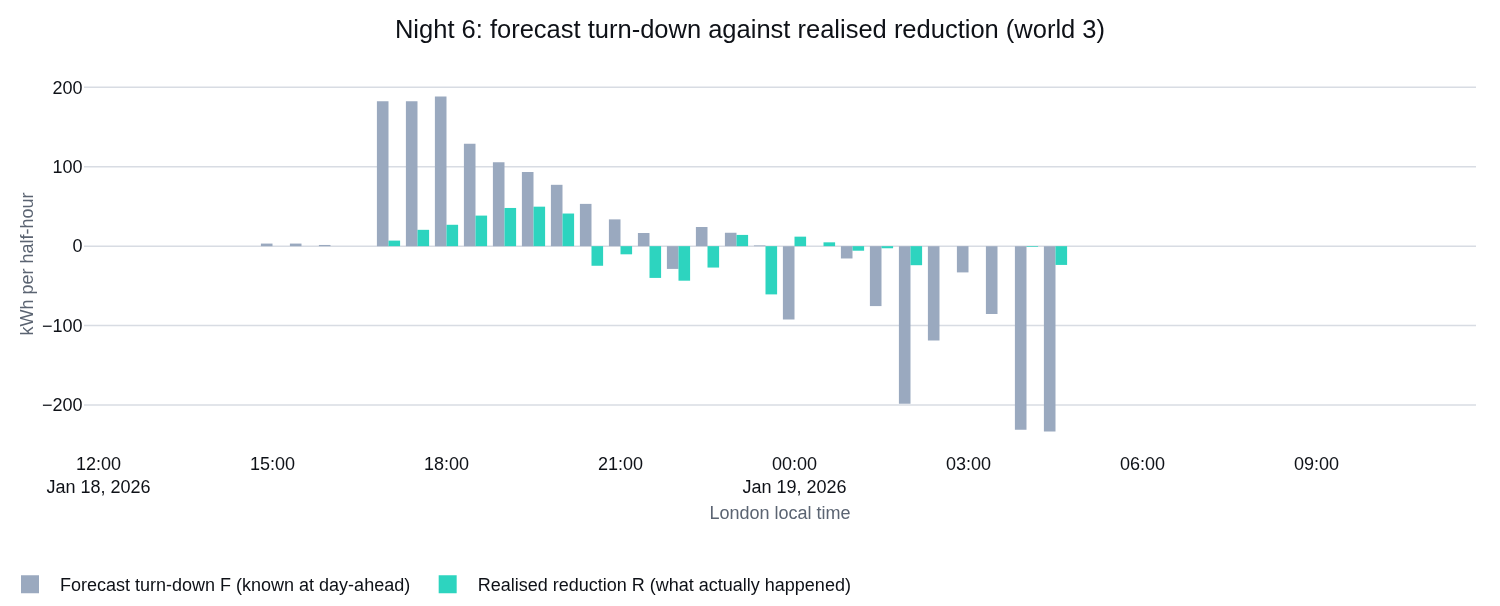

In [4]:
rep_world = base.representative_world_id
deviation = base.deviation_world_slot
rep_slots = deviation.query("world_id == @rep_world").sort_values("slot_index").copy()
rep_slots["forecast_reduction_kwh"] = (
    rep_slots["expected_unmanaged_kwh"] - rep_slots["expected_metered_kwh"]
)
rep_slots["hedge_error_contribution_gbp"] = (
    (rep_slots["true_reduction_kwh"] - rep_slots["forecast_reduction_kwh"])
    * (rep_slots["imbalance_gbp_per_mwh"] - rep_slots["day_ahead_gbp_per_mwh"])
    / 1000.0
)
night_hedge_error = rep_slots.groupby("night_index")["hedge_error_contribution_gbp"].sum()
best_night = int(night_hedge_error.abs().idxmax())
night_rows = rep_slots.loc[rep_slots["night_index"] == best_night]
night_london = night_rows["interval_start_london"]

hedge_figure = go.Figure()
hedge_figure.add_trace(
    go.Bar(
        x=night_london,
        y=night_rows["forecast_reduction_kwh"].round(2),
        name="Forecast turn-down F (known at day-ahead)",
        marker_color=SERIES_COLOURS["normal"],
    )
)
hedge_figure.add_trace(
    go.Bar(
        x=night_london,
        y=night_rows["true_reduction_kwh"].round(2),
        name="Realised reduction R (what actually happened)",
        marker_color=SERIES_COLOURS["selected"],
    )
)
hedge_figure.update_layout(
    barmode="group",
    title=f"Night {best_night}: forecast turn-down against realised reduction (world {rep_world})",
    xaxis_title="London local time",
    yaxis_title="kWh per half-hour",
)
apply_notebook_style(hedge_figure, height=360)

In [5]:
night_table = night_rows[
    [
        "interval_start_london",
        "true_reduction_kwh",
        "forecast_reduction_kwh",
        "hedge_error_contribution_gbp",
    ]
].copy()
night_table["interval_start_london"] = night_table["interval_start_london"].dt.strftime("%a %H:%M")
night_table.round(3)

,interval_start_london,true_reduction_kwh,forecast_reduction_kwh,hedge_error_contribution_gbp
1296,Sun 12:00,-0.000,0.000,0.000
1297,Sun 12:30,0.000,0.000,0.000
1298,Sun 13:00,0.000,0.000,0.000
1299,Sun 13:30,0.000,0.000,0.000
1300,Sun 14:00,0.000,0.000,0.000
1301,Sun 14:30,0.000,0.000,0.000
1302,Sun 15:00,0.000,3.258,-0.041
1303,Sun 15:30,0.000,3.258,-0.045
1304,Sun 16:00,0.000,1.501,-0.039
1305,Sun 16:30,0.000,0.000,0.000


In [6]:
checks["toy: gross gain matches the worked example (GBP0.46/week)"] = np.isclose(
    toy_unset["gross_gain_gbp"].iloc[0], 0.46
)
checks["toy: a mis-timed x^U and x leaves the paired hedge-error saving unchanged"] = np.allclose(
    toy_unset["hedge_error_saving_gbp"].to_numpy(), toy_bias["hedge_error_saving_gbp"].to_numpy()
)
checks["toy: an unset platform fee makes the after-fee net unavailable (NaN), not GBP0"] = bool(
    toy_unset["net_gain_gbp"].isna().all()
)
checks["toy: a GBP1/EV/month fee gives the contract's own hand value (-GBP0.4615/week)"] = (
    np.isclose(toy_fee["platform_fee_gbp"].iloc[0], -1 * 2 * 12 / 52)
)
week_hedge_error_profiled = rep_slots["hedge_error_contribution_gbp"].sum()
stored_hedge_error = base.supplier_pnl_world.query(
    "world_id == @rep_world and hedge_variant == 'profiled'"
)["hedge_error_saving_gbp"].iloc[0]
checks["real run: hedge-error saving recomputes exactly from R, F and (SIP-P)"] = np.isclose(
    week_hedge_error_profiled, stored_hedge_error, atol=1e-6
)
by_night_forecast = rep_slots.groupby("night_index")["forecast_reduction_kwh"].sum()
checks["real run: the forecast turn-down F sums to 0 over every night (section 2 change)"] = (
    by_night_forecast.abs().max() < 1e-6
)

## 2. The four supplier P&L components, before and after the fee

Decision 0006 defines one net "illustrative simulated supplier gain" per treated customer per
month, from the supplier's own point of view (positive = gain), as the sum of four components,
each per simulated week:

1. **Energy procurement saving** at the day-ahead price -- exactly minus the Value-and-risk
   lens's own home-import cost difference (reused, never recomputed twice), split "of which" into
   a shape saving (the load moved to cheaper half-hours) and a volume value (any change in total
   energy).
2. **Hedge-error saving** at (imbalance minus day-ahead), against the like-for-like profiled hedge
   of section 1, shown beside its flat-block alternative.
3. **Grid-event payments**, third-party cash (GBP0 unless a grid-event preset is switched on).
4. **Customer payment** (negative): either a share of the supplier's own positive weekly gain, or
   a flat GBP/EV/month reward that is unset by default.

An optional **platform fee** (component 5) is a fifth, separate line: it is unavailable (NaN),
never GBP0, until it is set, and the headline this notebook (and the lens) shows is the
**before-fee** net.

**Why the trading ledger is shown beside, and never added.** The smart supplier's hedge already
leaves out the turn-down the aggregator sold, so components 1 and 2 already hold the value the
ledger's own day-ahead and imbalance buckets hold, from the other side of the same trade. Adding
the ledger's net to this P&L would value the same shifted energy twice. The only ledger bucket
this P&L reads at all is the third-party grid-event payment (component 3) -- nothing here touches
`day_ahead_revenue_gbp`, `intraday_pnl_gbp`, `trading_cost_gbp`, `imbalance_gbp`,
`baseline_effect_gbp` or the three deduction buckets. So an assumption that only moves one of
*those* ledger buckets should move the ledger's own net and leave this P&L untouched -- the check
at the end of this section does exactly that, editing `trading.half_spread_gbp_per_mwh` (the
intraday bid-ask spread the aggregator pays; a record `model/assumptions.py` itself labels
"ledger-only").

**Flat-tariff assumption.** This P&L assumes the customer pays the same flat p/kWh whenever the EV
charges, so the supplier keeps the whole procurement saving and pays the customer only through
component 4. (The household contract's own customer-value frames, section 7 below, take the
opposite **pass-through** reading -- as if the day-ahead price reached the customer -- and the
two readings of the same shifted energy are never added.)


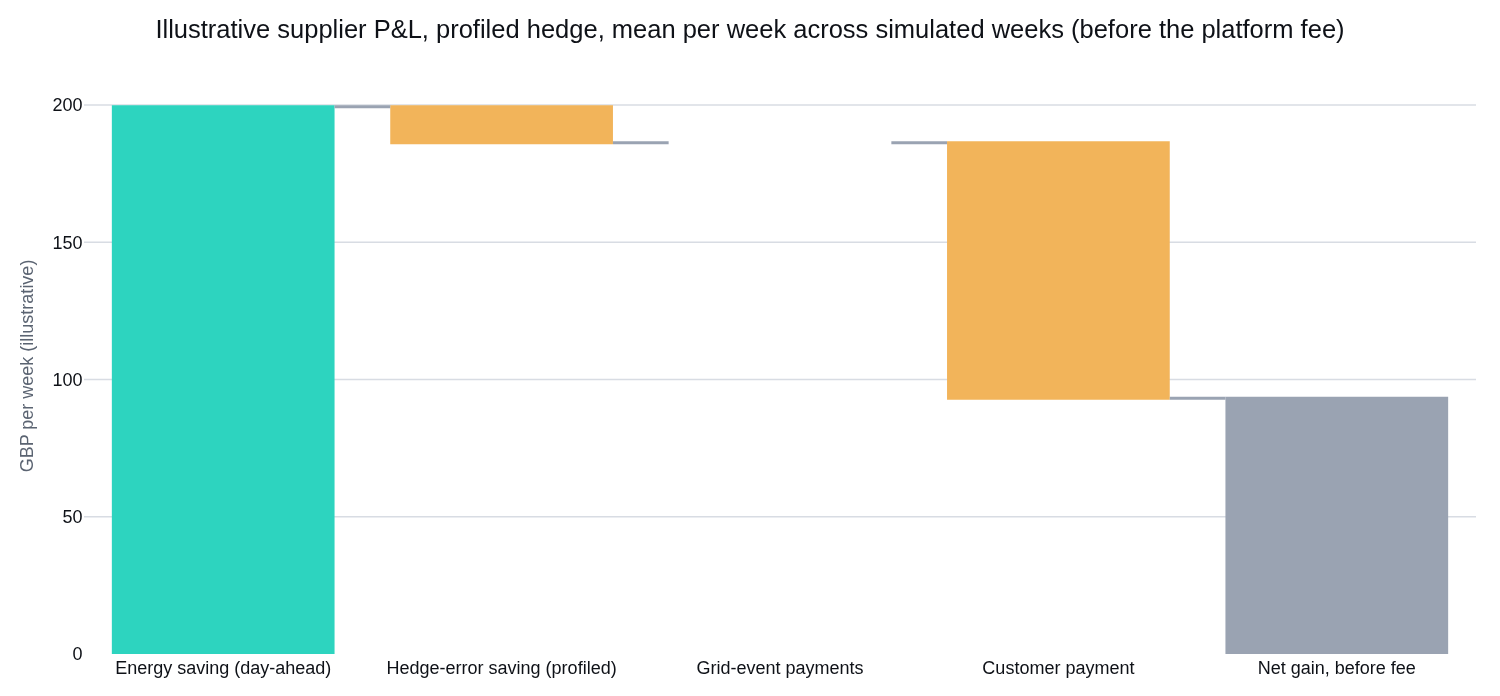

In [7]:
profiled_summary = base.supplier_pnl_summary.query("hedge_variant == 'profiled'").set_index(
    "metric"
)
component_order = [
    "energy_saving_gbp",
    "hedge_error_saving_gbp",
    "grid_event_payment_gbp",
    "customer_payment_gbp",
]
component_labels = {
    "energy_saving_gbp": "Energy saving (day-ahead)",
    "hedge_error_saving_gbp": "Hedge-error saving (profiled)",
    "grid_event_payment_gbp": "Grid-event payments",
    "customer_payment_gbp": "Customer payment",
    "net_gain_before_fee_gbp": "Net gain, before fee",
}
component_means = profiled_summary.loc[component_order, "mean"]

pnl_waterfall = go.Figure(
    go.Waterfall(
        x=[component_labels[name] for name in component_order]
        + [component_labels["net_gain_before_fee_gbp"]],
        y=list(component_means.round(2))
        + [round(float(profiled_summary.loc["net_gain_before_fee_gbp", "mean"]), 2)],
        measure=["relative"] * len(component_order) + ["total"],
        connector={"line": {"color": MUTED_INK}},
        increasing={"marker": {"color": SERIES_COLOURS["selected"]}},
        decreasing={"marker": {"color": SERIES_COLOURS["difference"]}},
        totals={"marker": {"color": MUTED_INK}},
    )
)
pnl_waterfall.update_layout(
    title=(
        "Illustrative supplier P&L, profiled hedge, mean per week across simulated weeks "
        "(before the platform fee)"
    ),
    yaxis_title="GBP per week (illustrative)",
)
apply_notebook_style(pnl_waterfall, height=420)

In [8]:
component_table = profiled_summary.loc[
    [*component_order, "net_gain_before_fee_gbp"],
    ["unit", "horizon", "world_count", "mean", "p10", "p50", "p90"],
].rename(index=component_labels)
component_table.round(3)

,unit,horizon,world_count,mean,p10,p50,p90
metric,,,,,,,
Energy saving (day-ahead),GBP per week,week_ahead,8,199.351,178.702,195.929,231.121
Hedge-error saving (profiled),GBP per week,week_ahead,8,-13.090,-41.105,-36.175,30.958
Grid-event payments,GBP per week,week_ahead,8,0.000,0.000,0.000,0.000
Customer payment,GBP per week,week_ahead,8,-93.131,-121.669,-90.051,-70.565
"Net gain, before fee",GBP per week,week_ahead,8,93.131,70.565,90.051,121.669


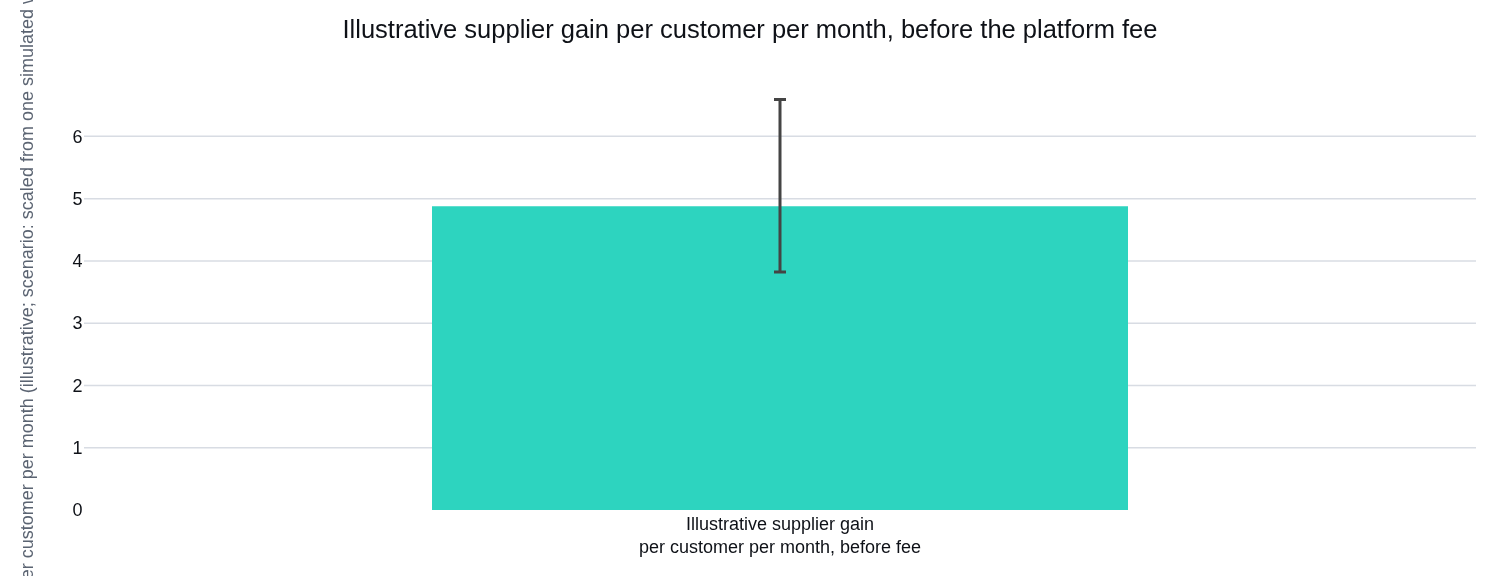

In [9]:
per_customer = profiled_summary.loc["net_gain_before_fee_per_customer_per_month_gbp"]
per_customer_figure = go.Figure(
    go.Bar(
        x=["Illustrative supplier gain<br>per customer per month, before fee"],
        y=[per_customer["p50"]],
        error_y={
            "type": "data",
            "symmetric": False,
            "array": [per_customer["p90"] - per_customer["p50"]],
            "arrayminus": [per_customer["p50"] - per_customer["p10"]],
        },
        marker_color=SERIES_COLOURS["selected"],
        width=[0.5],
    )
)
per_customer_figure.update_layout(
    title="Illustrative supplier gain per customer per month, before the platform fee",
    yaxis_title=(
        "GBP per customer per month (illustrative; scenario: scaled from one simulated week)"
    ),
    showlegend=False,
)
apply_notebook_style(per_customer_figure, height=340)

In [10]:
ledger_reference = base.trading_kpis.query("strategy == 'full' and metric == 'net_gbp_per_week'")[
    "mean"
].iloc[0]
fee_row = profiled_summary.loc["platform_fee_gbp"]
net_row = profiled_summary.loc["net_gain_gbp"]

reference_table = pd.DataFrame(
    [
        {
            "figure": "Supplier gain per customer per month, before fee (P50)",
            "value": per_customer["p50"],
            "unit": "GBP per customer per month",
        },
        {
            "figure": "Trading ledger net, aggregator, strategy 'full' (beside, never added)",
            "value": ledger_reference,
            "unit": "GBP per week, fleet mean",
        },
        {
            "figure": "Platform fee",
            "value": "Unavailable: not set" if fee_row["world_count"] == 0 else fee_row["mean"],
            "unit": "GBP per week, fleet mean",
        },
        {
            "figure": "Net gain, after fee",
            "value": (
                "Unavailable: platform fee not set"
                if net_row["world_count"] == 0
                else net_row["mean"]
            ),
            "unit": "GBP per week, fleet mean",
        },
    ]
)
reference_table

,figure,value,unit
0,"Supplier gain per customer per month, before f...",4.877767,GBP per customer per month
1,"Trading ledger net, aggregator, strategy 'full...",200.203337,"GBP per week, fleet mean"
2,Platform fee,Unavailable: not set,"GBP per week, fleet mean"
3,"Net gain, after fee",Unavailable: platform fee not set,"GBP per week, fleet mean"


In [11]:
pnl_world_profiled = base.supplier_pnl_world.query("hedge_variant == 'profiled'")
checks["every world: gross gain = energy saving + hedge-error saving + grid-event payment"] = (
    np.allclose(
        pnl_world_profiled["gross_gain_gbp"],
        pnl_world_profiled["energy_saving_gbp"]
        + pnl_world_profiled["hedge_error_saving_gbp"]
        + pnl_world_profiled["grid_event_payment_gbp"],
    )
)
checks["every world: net before fee = gross gain + customer payment"] = np.allclose(
    pnl_world_profiled["net_gain_before_fee_gbp"],
    pnl_world_profiled["gross_gain_gbp"] + pnl_world_profiled["customer_payment_gbp"],
)
checks[
    "every world: energy saving equals minus the Value-and-risk lens's own cost_effect column"
] = np.allclose(
    pnl_world_profiled.sort_values("world_id")["energy_saving_gbp"].to_numpy(),
    -base.cost_effect.sort_values("world_id")[
        "illustrative_selected_minus_normal_energy_cost_gbp"
    ].to_numpy(),
)
checks["every world: shape saving + volume value = energy saving ('of which')"] = np.allclose(
    pnl_world_profiled["shape_saving_gbp"] + pnl_world_profiled["volume_value_gbp"],
    pnl_world_profiled["energy_saving_gbp"],
)
checks["fee unset: the platform fee and the after-fee net are unavailable, not GBP0"] = bool(
    fee_row["world_count"] == 0
    and np.isnan(fee_row["mean"])
    and net_row["world_count"] == 0
    and np.isnan(net_row["mean"])
)

# Both runs with intraday dispatch off (see "Try it"): with dispatch on, the half spread also
# sets the re-plan bar and so moves the dispatched fleet the supplier P&L reads.
DISPATCH_OFF = {"trading.intraday_dispatch": 0.0}
ledger_only_base = run_scenario(START_LOCAL_DATE, values=RUN_VALUES, trading_overrides=DISPATCH_OFF)
ledger_only_run = run_scenario(
    START_LOCAL_DATE,
    values=RUN_VALUES,
    # default is GBP1/MWh
    trading_overrides={**DISPATCH_OFF, "trading.half_spread_gbp_per_mwh": 15.0},
)
ledger_cost_before = ledger_only_base.trading_week_world.query("strategy == 'full'")[
    "trading_cost_gbp"
].sum()
ledger_cost_after = ledger_only_run.trading_week_world.query("strategy == 'full'")[
    "trading_cost_gbp"
].sum()
checks[
    "dispatch off, ledger-only edit (intraday half spread): the ledger's trading cost moved"
] = not np.isclose(ledger_cost_before, ledger_cost_after)
checks[
    "dispatch off, ledger-only record edited: the supplier P&L frame is bit-for-bit unchanged"
] = ledger_only_base.supplier_pnl_world.equals(ledger_only_run.supplier_pnl_world)

ledger_only_table = pd.DataFrame(
    [
        {
            "half spread (record), dispatch off": "GBP1/MWh (default)",
            "ledger trading cost, GBP/week (sum over worlds)": ledger_cost_before,
            "supplier P&L identical to the default run": True,
        },
        {
            "half spread (record), dispatch off": "GBP15/MWh (try it)",
            "ledger trading cost, GBP/week (sum over worlds)": ledger_cost_after,
            "supplier P&L identical to the default run": ledger_only_base.supplier_pnl_world.equals(
                ledger_only_run.supplier_pnl_world
            ),
        },
    ]
)
ledger_only_table.round(2)

,"half spread (record), dispatch off","ledger trading cost, GBP/week (sum over worlds)",supplier P&L identical to the default run
0,GBP1/MWh (default),-20.21,True
1,GBP15/MWh (try it),-303.08,True


## 3. Hedge blocks: baseload, peak and off-peak

A supplier does not buy one shapeless day-ahead block; it typically buys `baseload` (every
half-hour), `peak` (07:00-19:00 London, Monday-Friday by calendar date) and `off-peak` (the
remainder). `hedge_block_world`/`hedge_block_summary` (supplier contract v1 section 3.7) read the
block hours **from this run's own `study_slots`**, never from a hard-coded hour count: a
clock-change week's short or long last day changes the peak block's own hour total, and the frame
derives and stores the value so the check below is explicit rather than typed in by hand. The
headline is the **peak block's mean-MW requirement change** (`difference`, selected minus normal):
negative when smart charging moves energy out of the peak.


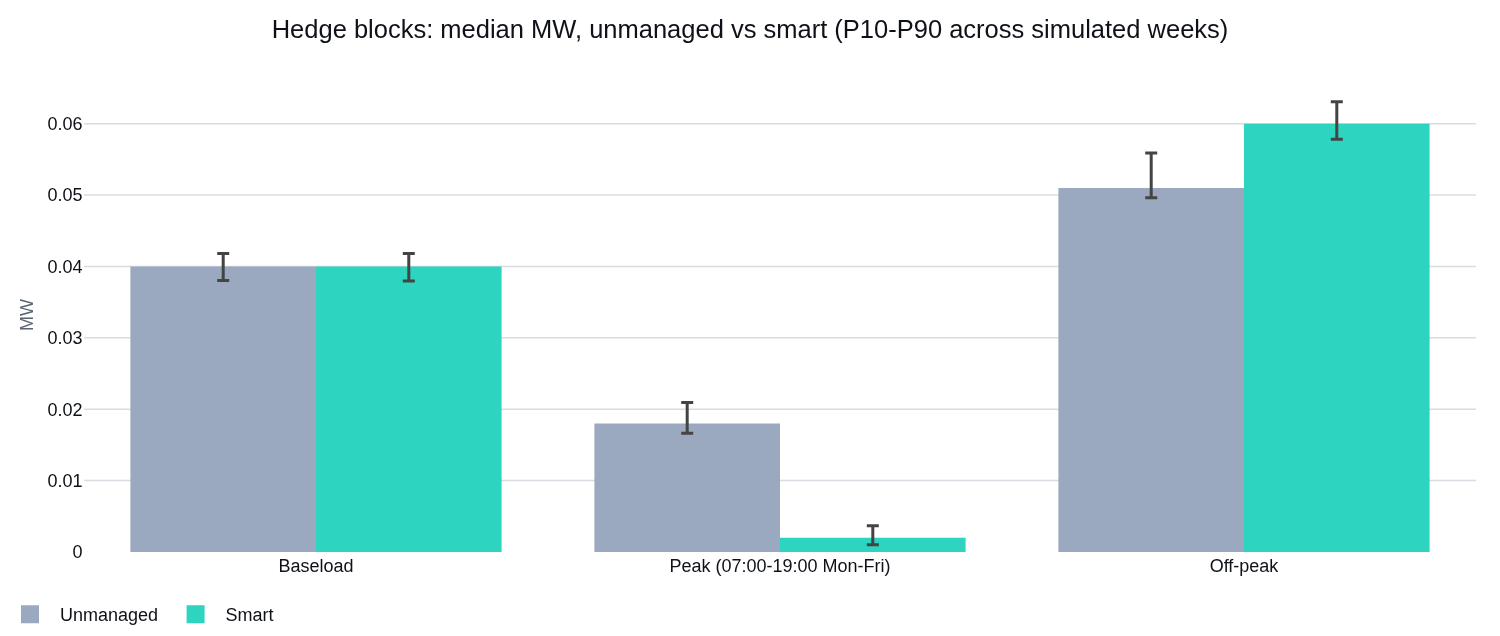

In [12]:
hedge_blocks = base.hedge_block_summary.query("metric == 'mean_mw'")
block_labels = {
    "baseload": "Baseload",
    "peak": "Peak (07:00-19:00 Mon-Fri)",
    "off_peak": "Off-peak",
}
path_labels = {"normal": "Unmanaged", "selected": "Smart"}

blocks_figure = go.Figure()
for path in ("normal", "selected"):
    rows = hedge_blocks.query("path_id == @path").set_index("block").loc[list(block_labels)]
    blocks_figure.add_trace(
        go.Bar(
            x=[block_labels[b] for b in block_labels],
            y=rows["p50"].round(3),
            error_y={
                "type": "data",
                "symmetric": False,
                "array": rows["p90"] - rows["p50"],
                "arrayminus": rows["p50"] - rows["p10"],
            },
            name=path_labels[path],
            marker_color=SERIES_COLOURS[path],
        )
    )
blocks_figure.update_layout(
    barmode="group",
    title="Hedge blocks: median MW, unmanaged vs smart (P10-P90 across simulated weeks)",
    yaxis_title="MW",
)
apply_notebook_style(blocks_figure, height=380)

In [13]:
hedge_block_table = hedge_blocks.pivot_table(
    index="block", columns="path_id", values=["mean", "p10", "p50", "p90"]
).loc[list(block_labels)]
hedge_block_table.round(4)

mean                         p10                         p50                         p90          \
path_id  difference  normal selected difference  normal selected difference  normal selected difference  normal   
block                                                                                                             
baseload     0.0000  0.0398   0.0398    -0.0000  0.0379   0.0379     0.0000  0.0399   0.0399     0.0000  0.0417   
peak        -0.0160  0.0182   0.0022    -0.0186  0.0165   0.0010    -0.0159  0.0178   0.0020    -0.0137  0.0208   
off_peak     0.0089  0.0518   0.0607     0.0076  0.0492   0.0582     0.0088  0.0506   0.0603     0.0104  0.0555   

                   
path_id  selected  
block              
baseload   0.0417  
peak       0.0036  
off_peak   0.0634

In [14]:
block_hours_row = base.hedge_block_world.drop_duplicates("block").set_index("block")["block_hours"]
checks["hedge blocks: baseload hours derive from this run's own study_slots (0.5 x slot count)"] = (
    np.isclose(block_hours_row["baseload"], 0.5 * len(base.study_slots))
)
volume_by_block = base.hedge_block_world.pivot_table(
    index=["world_id", "path_id"], columns="block", values="volume_mwh"
)
checks["hedge blocks: baseload volume = peak + off-peak volume, every world and path"] = (
    np.allclose(volume_by_block["baseload"], volume_by_block[["peak", "off_peak"]].sum(axis=1))
)
diff_volume = (
    base.hedge_block_world.query("path_id == 'difference'")
    .sort_values(["world_id", "block"])["volume_mwh"]
    .to_numpy()
)
selected_volume = (
    base.hedge_block_world.query("path_id == 'selected'")
    .sort_values(["world_id", "block"])["volume_mwh"]
    .to_numpy()
)
normal_volume = (
    base.hedge_block_world.query("path_id == 'normal'")
    .sort_values(["world_id", "block"])["volume_mwh"]
    .to_numpy()
)
checks[
    "hedge blocks: the 'difference' row is exactly selected minus normal, every world and block"
] = np.allclose(diff_volume, selected_volume - normal_volume)

## 4. CO2 shifted

An illustrative synthetic carbon intensity tied to the model's own system net demand (not observed
grid data): low net demand leaves a clean margin, high net demand is filled by gas up to a cap.
`supplier.carbon_intensity_gco2_per_kwh` (supplier contract v1 section 3.8) is a public function --
the household contract reads per-EV CO2 from the exact same rule, so the fleet figure here and a
customer's own figure in section 7 can never disagree about what a kWh of turn-down is worth in
carbon terms.


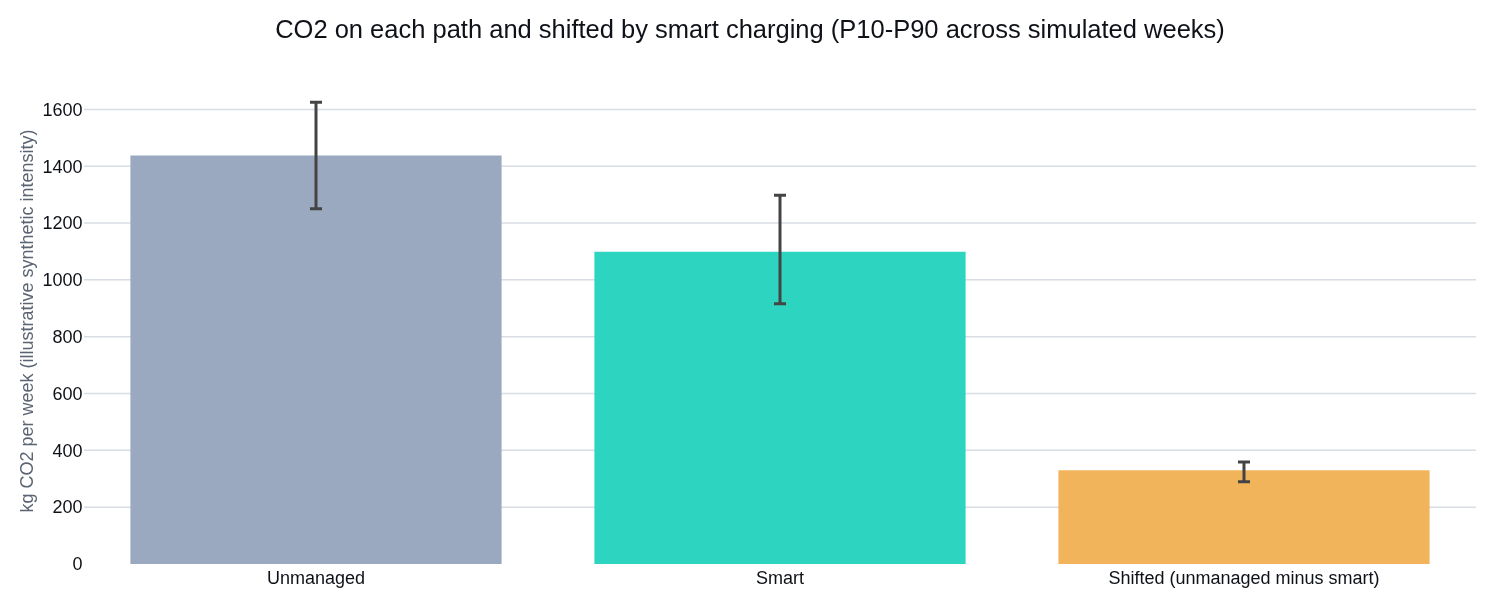

In [15]:
carbon_summary = base.carbon_shift_summary.set_index("metric")
carbon_labels = {
    "co2_unmanaged_kg": "Unmanaged",
    "co2_smart_kg": "Smart",
    "co2_shifted_kg": "Shifted (unmanaged minus smart)",
}
carbon_weekly = carbon_summary.loc[list(carbon_labels)]

carbon_figure = go.Figure(
    go.Bar(
        x=[carbon_labels[m] for m in carbon_labels],
        y=carbon_weekly["p50"].round(1),
        error_y={
            "type": "data",
            "symmetric": False,
            "array": carbon_weekly["p90"] - carbon_weekly["p50"],
            "arrayminus": carbon_weekly["p50"] - carbon_weekly["p10"],
        },
        marker_color=[
            SERIES_COLOURS["normal"],
            SERIES_COLOURS["selected"],
            SERIES_COLOURS["difference"],
        ],
    )
)
carbon_figure.update_layout(
    title="CO2 on each path and shifted by smart charging (P10-P90 across simulated weeks)",
    yaxis_title="kg CO2 per week (illustrative synthetic intensity)",
    showlegend=False,
)
apply_notebook_style(carbon_figure, height=360)

In [16]:
carbon_summary.loc[
    ["co2_unmanaged_kg", "co2_smart_kg", "co2_shifted_kg", "co2_shifted_kg_per_ev_per_month"],
    ["unit", "horizon", "world_count", "mean", "p10", "p50", "p90"],
].round(3)

,unit,horizon,world_count,mean,p10,p50,p90
metric,,,,,,,
co2_unmanaged_kg,kg CO2 per week,week_ahead,8,1439.336,1250.290,1437.738,1624.937
co2_smart_kg,kg CO2 per week,week_ahead,8,1113.778,916.248,1099.171,1297.850
co2_shifted_kg,kg CO2 per week,week_ahead,8,325.558,289.487,329.795,358.959
co2_shifted_kg_per_ev_per_month,kg CO2 per EV per month,scenario,8,17.634,15.681,17.864,19.444


In [17]:
def _slot_matrix(frame: pd.DataFrame, column: str, world_count: int) -> np.ndarray:
    return (
        frame.sort_values(["world_id", "slot_index"])[column]
        .to_numpy(dtype=float)
        .reshape(world_count, -1)
    )


TOY_NET_DEMAND_GW = np.array([[10.0, 20.0, 35.0]])
toy_carbon_records = {**supplier_defaults, "carbon.intensity_slope_gco2_per_kwh_per_gw": 0.0}
toy_intensity = supplier_model.carbon_intensity_gco2_per_kwh(
    TOY_NET_DEMAND_GW, toy_carbon_records, REFERENCE_NET_DEMAND_GW
)
checks["carbon toy: a zero slope makes intensity constant at the reference value"] = np.allclose(
    toy_intensity, toy_carbon_records["carbon.intensity_at_reference_gco2_per_kwh"]
)

unmanaged_matrix = _slot_matrix(base.deviation_world_slot, "unmanaged_kwh", base.world_count)
metered_matrix = _slot_matrix(base.deviation_world_slot, "metered_kwh", base.world_count)
net_demand_matrix = _slot_matrix(base.forecast_prices, "system_net_demand_gw", base.world_count)
intensity_matrix = supplier_model.carbon_intensity_gco2_per_kwh(
    net_demand_matrix, supplier_defaults, REFERENCE_NET_DEMAND_GW
)
co2_shifted_recomputed = (unmanaged_matrix - metered_matrix) * intensity_matrix
co2_shifted_recomputed = co2_shifted_recomputed.sum(axis=1) / 1000.0
checks["real run: CO2 shifted recomputes exactly from R and the intensity function"] = np.allclose(
    co2_shifted_recomputed,
    base.carbon_shift_world.sort_values("world_id")["co2_shifted_kg"].to_numpy(),
    atol=1e-6,
)

## 5. Partner measures and the GBP10 guarantee floor

A device maker's own question is different from the supplier's: not "did my customers save
money", but "what does my installed base earn me". `partner_world`/`partner_summary` (supplier
contract v1 section 4.2) answer it per group -- the fleet, each cohort, and each maker, now that
`units.manufacturer_id` exists in this run -- in **gross flexibility cash**: before the customer's
own share and any penalty, so it includes the ledger's baseline-effect bucket (which is not
flexibility on its own; every caption on this figure says so). An "earning" device is one that
*physically* turned down in at least one settled slot, not one whose allocated cash happened to be
positive, so a maker's own share-earning figure can never be gamed by the allocation rule.

`household_value_exceedance` (section 4.3) asks a different, marketing-facing question: what share
of enrolled customers clear a guaranteed GBP per month, and what would it cost to top up everyone
else to that floor? It always uses the pass-through customer value (as if the day-ahead price
reached the customer), independent of the supplier's own reward mode in section 2, and the two
readings of the same shifted energy are never added.


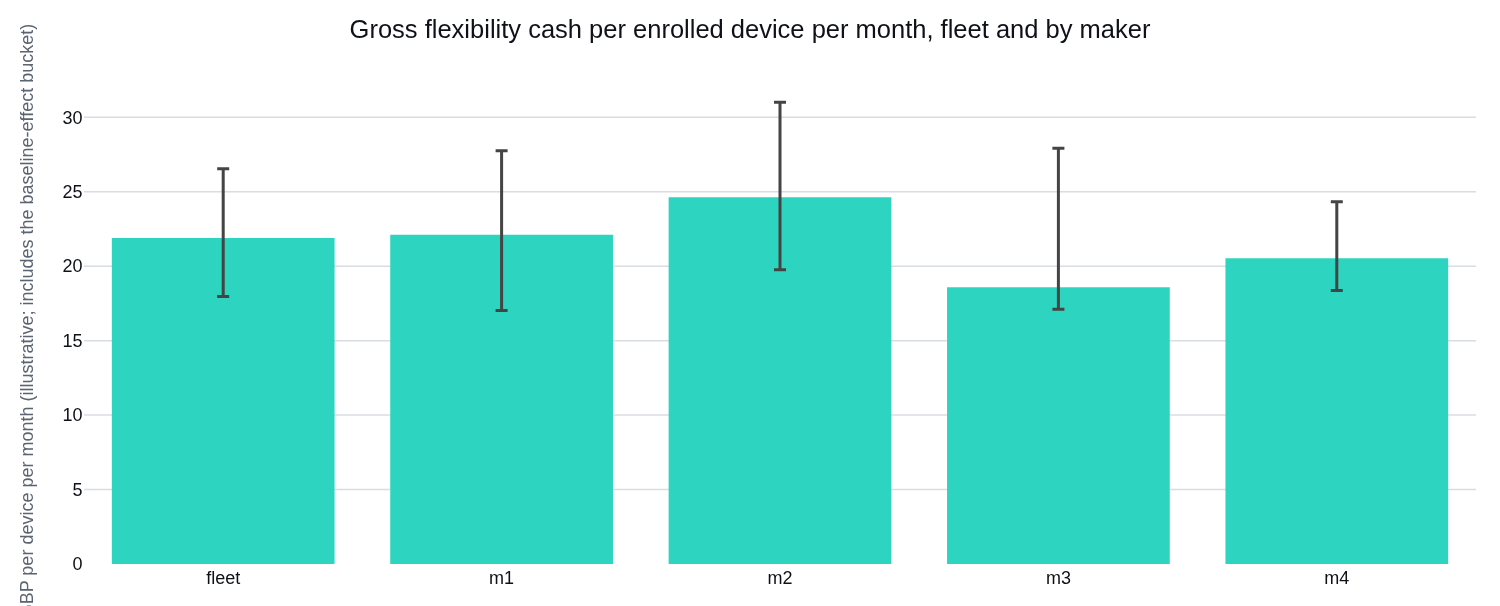

In [18]:
partner_groups_shown = ["fleet"] + sorted(
    base.partner_world.query("group_type == 'manufacturer'")["group_id"].unique()
)
HEADLINE_METRIC = "gross_flex_gbp_per_enrolled_device_per_month"
headline_rows = (
    base.partner_summary.query("group_id in @partner_groups_shown and metric == @HEADLINE_METRIC")
    .set_index("group_id")
    .loc[partner_groups_shown]
)

partner_figure = go.Figure(
    go.Bar(
        x=partner_groups_shown,
        y=headline_rows["p50"].round(3),
        error_y={
            "type": "data",
            "symmetric": False,
            "array": headline_rows["p90"] - headline_rows["p50"],
            "arrayminus": headline_rows["p50"] - headline_rows["p10"],
        },
        marker_color=SERIES_COLOURS["selected"],
    )
)
partner_figure.update_layout(
    title="Gross flexibility cash per enrolled device per month, fleet and by maker",
    yaxis_title="GBP per device per month (illustrative; includes the baseline-effect bucket)",
    showlegend=False,
)
apply_notebook_style(partner_figure, height=360)

In [19]:
partner_metric_names = [
    "gross_flex_gbp_per_enrolled_device_per_month",
    "share_earning",
    "gross_flex_gbp_per_earning_device_per_month",
    "gbp_per_kw_charger_per_year",
    # plan_status (J1b) landed, so this is the run's own dispatch success rate, not NaN.
    "dispatch_success_rate",
]
partner_table = (
    base.partner_summary.query(
        "group_id in @partner_groups_shown and metric in @partner_metric_names"
    )
    .pivot_table(index="group_id", columns="metric", values="p50")
    .loc[partner_groups_shown, partner_metric_names]
)
partner_table.round(3)

metric,gross_flex_gbp_per_enrolled_device_per_month,share_earning,gross_flex_gbp_per_earning_device_per_month,gbp_per_kw_charger_per_year,dispatch_success_rate
group_id,,,,,
fleet,21.900,0.956,23.377,37.543,0.908
m1,22.104,0.975,22.810,37.892,0.936
m2,24.623,0.950,26.224,42.211,0.940
m3,18.579,0.975,18.579,31.851,0.936
m4,20.540,0.950,23.039,35.211,0.930


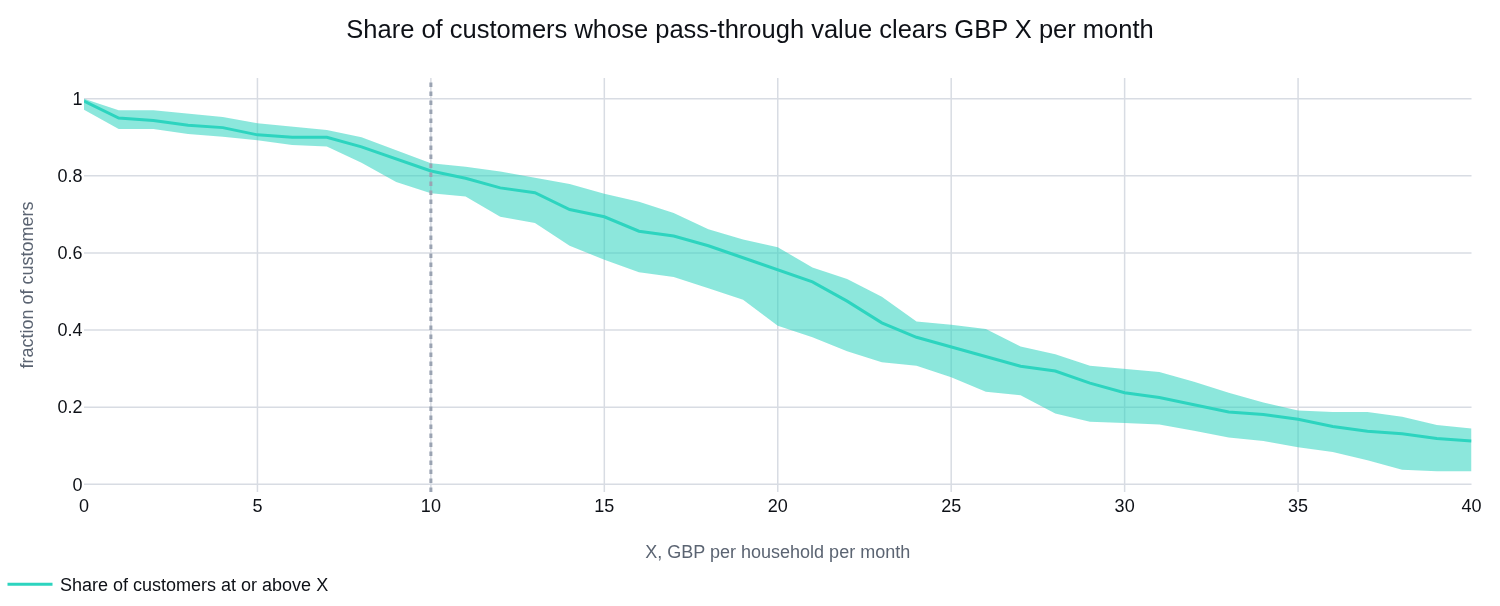

In [20]:
EXCEEDANCE_THRESHOLD_TRY_IT = 10  # GBP per household per month; the lens default
exceedance_fleet = base.household_value_exceedance.query("group_id == 'fleet'")
share_rows = exceedance_fleet.query("metric == 'share_at_or_above'").sort_values(
    "threshold_gbp_per_month"
)

exceedance_figure = go.Figure()
band_and_line(
    exceedance_figure,
    share_rows["threshold_gbp_per_month"],
    share_rows["p10"],
    share_rows["p50"],
    share_rows["p90"],
    name="Share of customers at or above X",
    colour=SERIES_COLOURS["selected"],
)
exceedance_figure.add_vline(x=EXCEEDANCE_THRESHOLD_TRY_IT, line={"color": MUTED_INK, "dash": "dot"})
exceedance_figure.update_layout(
    title="Share of customers whose pass-through value clears GBP X per month",
    xaxis_title="X, GBP per household per month",
    yaxis_title="fraction of customers",
)
apply_notebook_style(exceedance_figure, height=360)

In [21]:
exceedance_table = exceedance_fleet.query(
    "threshold_gbp_per_month == @EXCEEDANCE_THRESHOLD_TRY_IT"
)[["metric", "unit", "world_count", "mean", "p10", "p50", "p90"]]
exceedance_table.round(3)

,metric,unit,world_count,mean,p10,p50,p90
10,share_at_or_above,fraction,8,0.802,0.755,0.812,0.832
51,floor_top_up_gbp_per_device_per_month,GBP per device per month,8,0.949,0.766,0.976,1.130


In [22]:
cohort_sum = (
    base.partner_world.query("group_type == 'cohort'")
    .groupby("world_id")["gross_flex_gbp_per_week"]
    .sum()
    .sort_index()
)
maker_sum = (
    base.partner_world.query("group_type == 'manufacturer'")
    .groupby("world_id")["gross_flex_gbp_per_week"]
    .sum()
    .sort_index()
)
fleet_gross_per_week_by_world = (
    base.partner_world.query("group_type == 'fleet'")
    .sort_values("world_id")["gross_flex_gbp_per_week"]
    .to_numpy()
)
checks["partners: cohort groups' gross flexibility cash sums to the fleet's, every world"] = (
    np.allclose(cohort_sum.to_numpy(), fleet_gross_per_week_by_world)
)
checks["partners: manufacturer groups' gross flexibility cash sums to the fleet's, every world"] = (
    np.allclose(maker_sum.to_numpy(), fleet_gross_per_week_by_world)
)

# The identity holds per world (contract section 4.7 id. 3), not for the cross-world means
# separately: mean(a * b) is not mean(a) * mean(b) in general, so the check reads partner_world.
fleet_world = base.partner_world.query("group_type == 'fleet'").sort_values("world_id")
earning_worlds = fleet_world["earning_ev_count"] > 0
checks["partners: share earning x per-earning-device = per-enrolled-device, every world"] = (
    np.allclose(
        (fleet_world["share_earning"] * fleet_world["gross_flex_gbp_per_earning_device_per_month"])[
            earning_worlds
        ],
        fleet_world["gross_flex_gbp_per_enrolled_device_per_month"][earning_worlds],
        rtol=1e-6,
    )
)

share_worse_off = base.household_value_summary.query(
    "group_id == 'fleet' and statistic == 'share_worse_off'"
)["mean"].iloc[0]
share_at_zero = base.household_value_exceedance.query(
    "group_id == 'fleet' and metric == 'share_at_or_above' and threshold_gbp_per_month == 0"
)["mean"].iloc[0]
checks[
    "exceedance: 1 - share_at_or_above(GBP0) equals the fleet's own share worse off, exactly"
] = np.isclose(1.0 - share_at_zero, share_worse_off, atol=1e-9)
checks["exceedance: share_at_or_above is non-increasing in the threshold, every step"] = bool(
    (share_rows["mean"].diff().dropna() <= 1e-9).all()
)

## 6. Revenue by market

`revenue_by_market_summary` (supplier contract v1 section 4.5) is the aggregator's own trading
ledger, strategy `full`, reorganised by market rather than by bucket: day-ahead, intraday,
imbalance and grid events (the four markets this model actually trades), then the baseline effect
(not a market) and the deductions (not income), then the net -- exactly the sum of the six rows
above it (means only; quantiles never add). Below them, four markets this fleet is **not** bid
into at all -- the Balancing Mechanism, frequency response, the Capacity Market, DNO services --
are listed by name with `modelled = False`, never shown as a silent GBP0 (decision 0005).


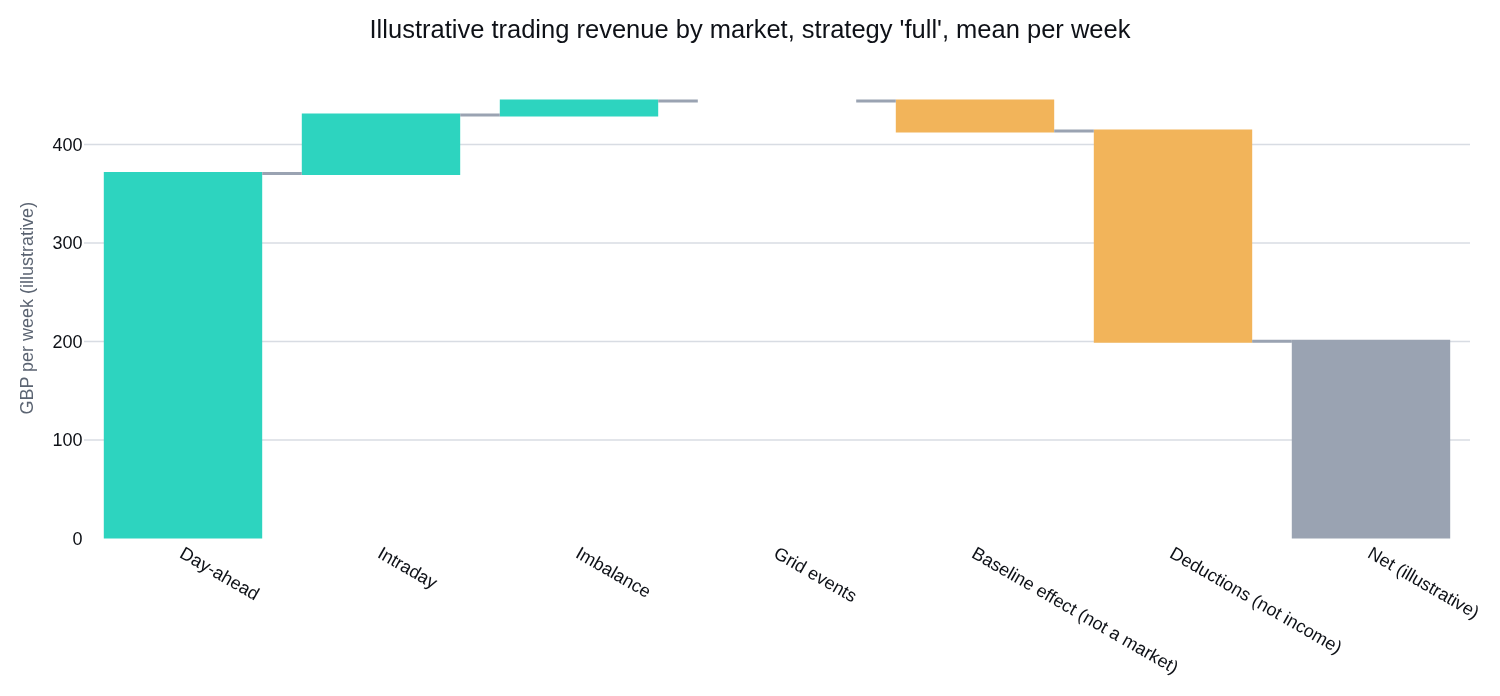

In [23]:
market_labels = {
    "day_ahead": "Day-ahead",
    "intraday": "Intraday",
    "imbalance": "Imbalance",
    "grid_events": "Grid events",
    "baseline_effect": "Baseline effect (not a market)",
    "deductions": "Deductions (not income)",
    "net": "Net (illustrative)",
}
weekly_market = base.revenue_by_market_summary.query("metric == 'gbp_per_week'").set_index("market")

market_waterfall = go.Figure(
    go.Waterfall(
        x=[market_labels[m] for m in market_labels],
        y=weekly_market.loc[list(market_labels), "mean"].round(2),
        measure=["relative"] * (len(market_labels) - 1) + ["total"],
        connector={"line": {"color": MUTED_INK}},
        increasing={"marker": {"color": SERIES_COLOURS["selected"]}},
        decreasing={"marker": {"color": SERIES_COLOURS["difference"]}},
        totals={"marker": {"color": MUTED_INK}},
    )
)
market_waterfall.update_layout(
    title="Illustrative trading revenue by market, strategy 'full', mean per week",
    yaxis_title="GBP per week (illustrative)",
)
apply_notebook_style(market_waterfall, height=420)

In [24]:
unmodelled_table = base.revenue_by_market_summary.query("metric == 'gbp_per_week'")[
    ["market", "modelled", "world_count", "mean", "p10", "p90"]
]
unmodelled_table

,market,modelled,world_count,mean,p10,p90
0,day_ahead,True,8,370.693013,320.437661,417.981721
2,intraday,True,8,59.177126,34.052342,79.265595
4,imbalance,True,8,14.293831,-5.290928,26.112310
6,grid_events,True,8,0.000000,0.000000,0.000000
8,baseline_effect,True,8,-30.346164,-67.074227,0.492316
10,deductions,True,8,-213.614469,-260.483222,-170.011611
12,net,True,8,200.203337,162.082794,235.062939
14,balancing_mechanism,False,0,NaN,NaN,NaN
16,frequency_response,False,0,NaN,NaN,NaN
18,capacity_market,False,0,NaN,NaN,NaN


In [25]:
modelled_weekly = base.revenue_by_market_summary.query("metric == 'gbp_per_week' and modelled")
modelled_by_market = modelled_weekly.set_index("market")
checks["revenue by market: the six modelled rows above net sum exactly to net (mean)"] = np.isclose(
    modelled_by_market.loc[
        ["day_ahead", "intraday", "imbalance", "grid_events", "baseline_effect", "deductions"],
        "mean",
    ].sum(),
    modelled_by_market.loc["net", "mean"],
    atol=1e-6,
)
checks["revenue by market: unmodelled markets carry NaN statistics, never a silent GBP0"] = bool(
    base.revenue_by_market_summary.query("not modelled")[["mean", "p10", "p50", "p90"]]
    .isna()
    .all()
    .all()
)

## 7. Household view: one customer, its archetype, the fleet

`household_card` (household contract v1 section 3.3, `model/household.py`) reads one EV's own
outcomes across every simulated week beside its cohort's and the fleet's, and its **percentile
rank** inside each group -- the same two stored frames (`household_ev_world`,
`household_outcomes_summary`) every group and marketing figure above already reads, so a
household's own card and the fleet's averages can never disagree.

**Typical-week wording.** A weekly figure's P10-P90 spread is taken across EVs *within* each
simulated week, then across weeks -- so "P50 across weeks" is a median of weekly medians, not one
"median week" (household contract v1 section 0; captions below say "medians across weeks").

**"8 in 10 customers" wording.** A yearly or monthly claim is never one week's across-customer
spread multiplied by 52 -- a customer's bad week and good week average out over a year, so that
would overstate the range. It reads **set B** instead: each customer's *own mean over every
simulated week* first, then the P10-P90 *across those customer means* -- "8 in 10 customers' own
average years are worth GBP P10 to GBP P90".


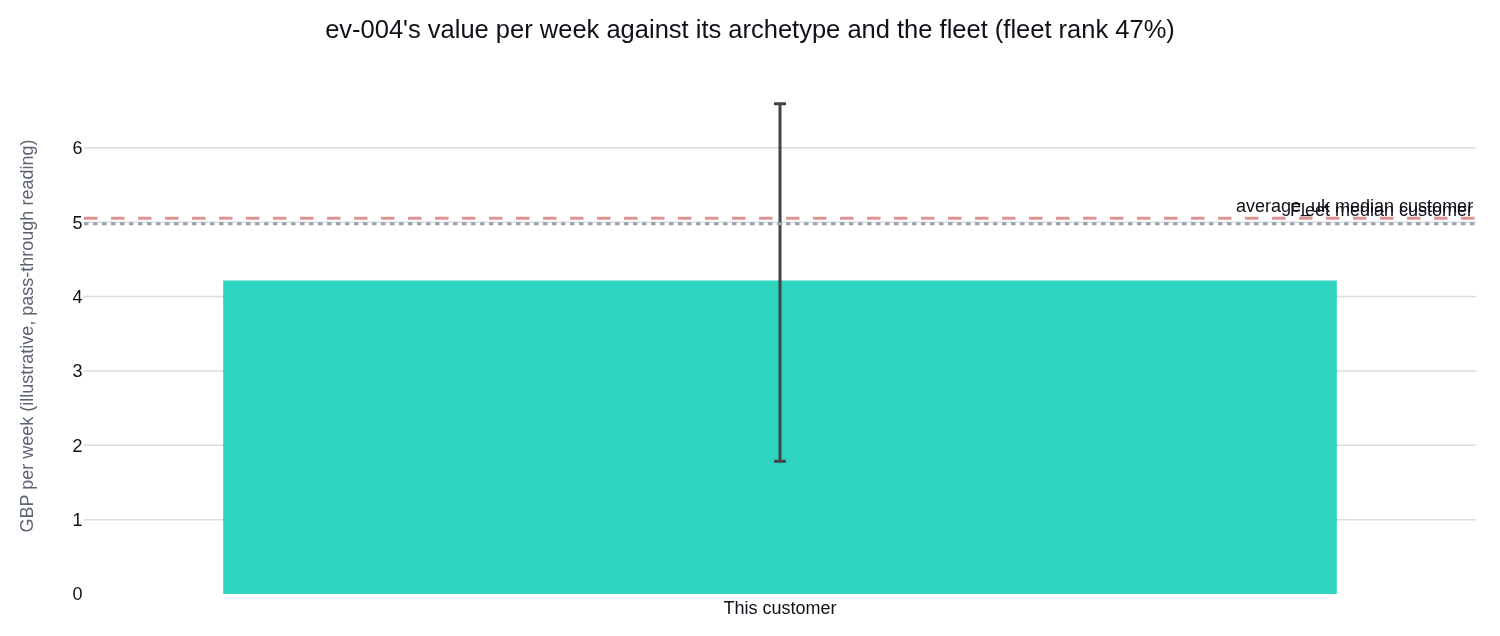

In [26]:
treated_units = (
    base.units.loc[~base.units["control_group"]]
    if "control_group" in base.units.columns
    else base.units
)
UNIT_ID_TRY_IT = treated_units["unit_id"].iloc[3]  # try another index, or another unit_id, here
card = household.household_card(base, UNIT_ID_TRY_IT)
outcomes = card.outcomes.set_index("metric")
week_row = outcomes.loc["value_gbp_per_week"]

card_figure = go.Figure()
card_figure.add_trace(
    go.Bar(
        x=["This customer"],
        y=[week_row["p50"]],
        error_y={
            "type": "data",
            "symmetric": False,
            "array": [week_row["p90"] - week_row["p50"]],
            "arrayminus": [week_row["p50"] - week_row["p10"]],
        },
        marker_color=SERIES_COLOURS["selected"],
        name="This customer (P10-P90 across weeks)",
    )
)
card_figure.add_hline(
    y=week_row["cohort_p50"],
    line={"color": ARCHETYPE_COLOURS[0], "dash": "dash"},
    annotation_text=f"{card.cohort_id} median customer",
)
card_figure.add_hline(
    y=week_row["fleet_p50"],
    line={"color": MUTED_INK, "dash": "dot"},
    annotation_text="Fleet median customer",
)
card_figure.update_layout(
    title=(
        f"{UNIT_ID_TRY_IT}'s value per week against its archetype and the fleet "
        f"(fleet rank {week_row['fleet_rank_p50']:.0%})"
    ),
    yaxis_title="GBP per week (illustrative, pass-through reading)",
    showlegend=False,
)
apply_notebook_style(card_figure, height=380)

In [27]:
# plan_status (J1b) has landed, so this EV's realised turn-down/turn-up availability profile
# is no longer None (household contract v1 section 3.3): the kernel's per-EV plan outputs exist.
print(f"{UNIT_ID_TRY_IT}: {len(card.availability)} availability rows, no longer None (J1b).")
card.availability_day.query("direction == 'turn_down'")[
    ["day_type", "local_time_label", "available_share", "p50", "firm_share"]
].head(6)

ev-004: 672 availability rows, no longer None (J1b).


,day_type,local_time_label,available_share,p50,firm_share
0,weekday,00:00,0.500,0.700000,0.0
1,weekday,00:30,0.375,0.000000,NaN
2,weekday,01:00,0.125,0.000000,NaN
3,weekday,01:30,0.500,0.330768,0.0
4,weekday,02:00,0.500,0.700000,0.0
5,weekday,02:30,0.375,0.000000,NaN


In [28]:
card_table = card.outcomes.loc[
    card.outcomes["metric"].isin(
        [
            "value_gbp_per_week",
            "value_gbp_per_year",
            "saving_gbp_per_week",
            "sessions_affected_share",
        ]
    ),
    [
        "metric",
        "unit",
        "horizon",
        "world_count",
        "mean",
        "p10",
        "p50",
        "p90",
        "cohort_p50",
        "fleet_p50",
        "cohort_rank_p50",
        "fleet_rank_p50",
    ],
]
card_table.round(3)

,metric,unit,horizon,world_count,mean,p10,p50,p90,cohort_p50,fleet_p50,cohort_rank_p50,fleet_rank_p50
0,value_gbp_per_week,GBP per week,week_ahead,8,4.160,1.786,4.218,6.592,5.052,4.979,0.344,0.469
2,value_gbp_per_year,GBP per year,scenario,8,216.321,NaN,NaN,NaN,260.681,260.681,0.094,0.312
3,saving_gbp_per_week,GBP per week,week_ahead,8,2.234,0.963,2.313,3.280,2.561,2.392,0.344,0.519
23,sessions_affected_share,fraction,week_ahead,8,0.000,0.000,0.000,0.000,0.000,0.000,0.969,0.974


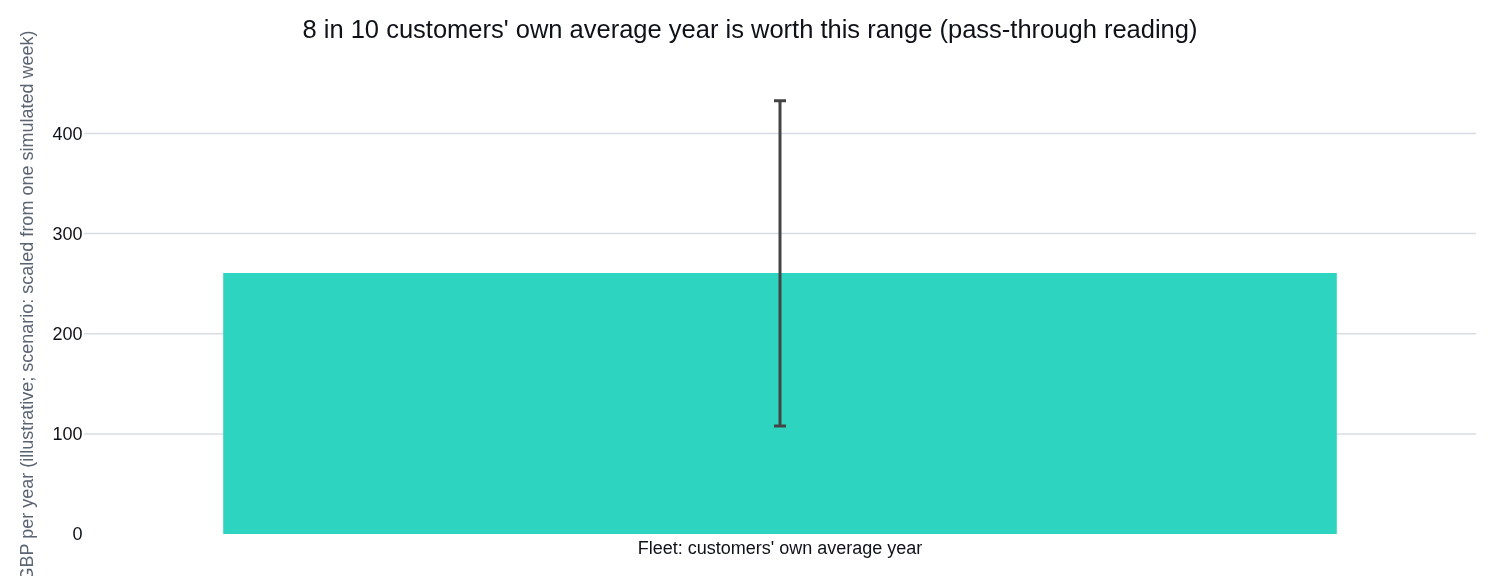

In [29]:
fleet_year_value = base.household_outcomes_summary.query(
    "group_id == 'fleet' and metric == 'value_gbp_per_year'"
).set_index("statistic")
p10_years = float(fleet_year_value.loc["p10_of_ev_means", "mean"])
p50_years = float(fleet_year_value.loc["p50_of_ev_means", "mean"])
p90_years = float(fleet_year_value.loc["p90_of_ev_means", "mean"])

eight_in_ten_figure = go.Figure(
    go.Bar(
        x=["Fleet: customers' own average year"],
        y=[p50_years],
        error_y={
            "type": "data",
            "symmetric": False,
            "array": [p90_years - p50_years],
            "arrayminus": [p50_years - p10_years],
        },
        marker_color=SERIES_COLOURS["selected"],
    )
)
eight_in_ten_figure.update_layout(
    title="8 in 10 customers' own average year is worth this range (pass-through reading)",
    yaxis_title="GBP per year (illustrative; scenario: scaled from one simulated week)",
    showlegend=False,
)
apply_notebook_style(eight_in_ten_figure, height=340)

In [30]:
fleet_year_value.loc[
    [
        "mean_of_ev_means",
        "p10_of_ev_means",
        "p50_of_ev_means",
        "p90_of_ev_means",
        "share_of_ev_means_below_zero",
    ],
    ["unit", "horizon", "world_count", "mean"],
]

,unit,horizon,world_count,mean
statistic,,,,
mean_of_ev_means,GBP per year,scenario,8,263.408040
p10_of_ev_means,GBP per year,scenario,8,107.751276
p50_of_ev_means,GBP per year,scenario,8,260.680953
p90_of_ev_means,GBP per year,scenario,8,432.644196
share_of_ev_means_below_zero,fraction,scenario,8,0.000000


In [31]:
ev_world_check = base.household_ev_world.query("unit_id == @UNIT_ID_TRY_IT").sort_values("world_id")
manual_week_value = ev_world_check["value_gbp_per_month"].to_numpy() * 12.0 / 52.0
checks["household card: this EV's own value-per-week matches a manual recompute"] = np.isclose(
    week_row["mean"], manual_week_value.mean(), atol=1e-6
) and np.isclose(week_row["p50"], np.quantile(manual_week_value, 0.5, method="linear"), atol=1e-6)
checks["household card: fleet and cohort ranks lie in [0, 1]"] = bool(
    0.0 <= week_row["fleet_rank_p50"] <= 1.0 and 0.0 <= week_row["cohort_rank_p50"] <= 1.0
)
checks["'8 in 10 customers': the fleet's average-year band is ordered P10 <= P50 <= P90"] = (
    p10_years <= p50_years <= p90_years
)

## 8. The growth calculator

`model/growth.py`'s five pure functions turn "GBP X per enrolled device per month"
(`partner_summary`, fleet, section 4.2) into the numbers a device maker's own sales conversation
needs: a sign-up funnel, a sensitivity read on which lever matters most, how many months of
revenue clears a subsidised sticker price, and a cumulative payout picture. None of this is
physics, policy or settlement -- it takes the presenter's own sales-funnel guesses as plain
arguments, so it is tested and lives in the model package, but the Streamlit lens computes
nothing itself. The funnel's three conversion shares, the take rate, the fee and the discount
below are **illustrative placeholders with no accepted source in this project** (supplier
contract v1 section 16 Q7; overnight review log, 30 Sep early) -- the model contributes only
`share_earning`, the run's own figure for what fraction of active devices actually turned down.


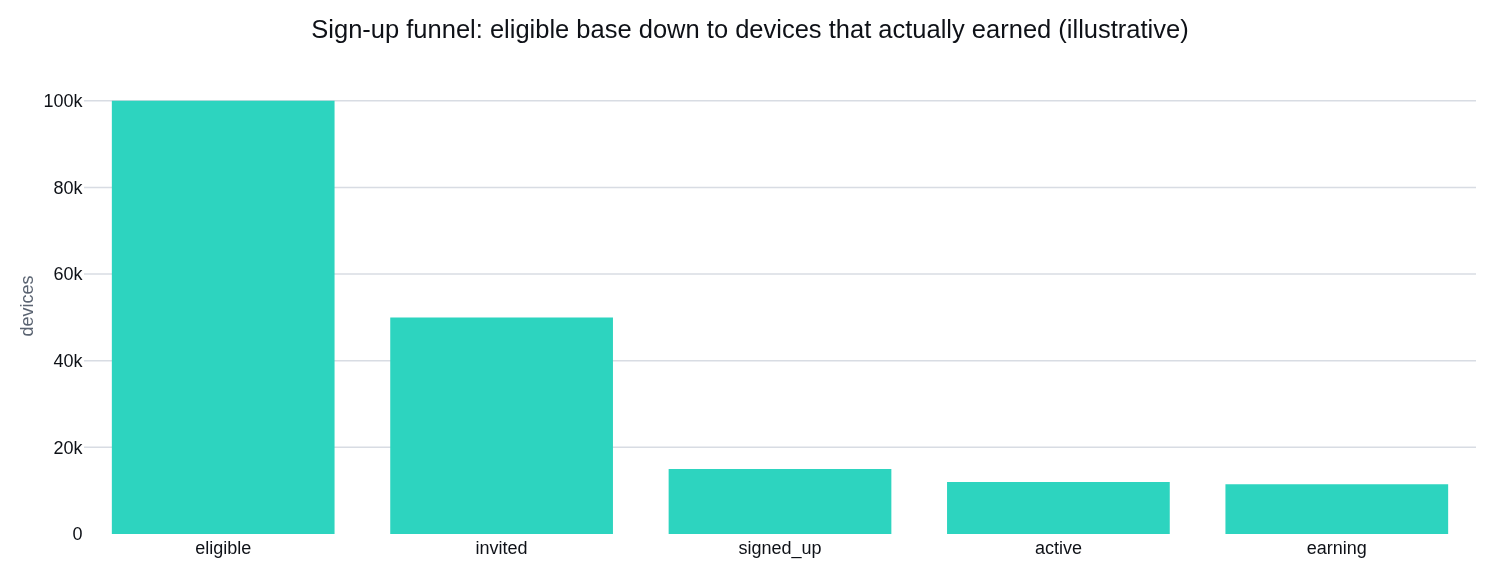

In [32]:
ELIGIBLE_TRY_IT = 100_000.0
INVITED_SHARE_TRY_IT = 0.5
SIGNED_UP_SHARE_TRY_IT = 0.3
ACTIVE_SHARE_TRY_IT = 0.8
TAKE_RATE_TRY_IT = 0.2
FEE_TRY_IT = 0.0  # GBP per device per month; 0.0 reads as "no fee set" (growth.tornado's own rule)
DISCOUNT_TRY_IT = 100.0  # GBP per device, a one-off sticker-price discount

fleet_gross_per_enrolled = base.partner_summary.query(
    "group_id == 'fleet' and metric == 'gross_flex_gbp_per_enrolled_device_per_month'"
).iloc[0]
fleet_share_earning = base.partner_summary.query(
    "group_id == 'fleet' and metric == 'share_earning'"
)["p50"].iloc[0]

funnel_table = growth.funnel(
    eligible=ELIGIBLE_TRY_IT,
    invited_share=INVITED_SHARE_TRY_IT,
    signed_up_share=SIGNED_UP_SHARE_TRY_IT,
    active_share=ACTIVE_SHARE_TRY_IT,
    share_earning=fleet_share_earning,
)

funnel_figure = go.Figure(
    go.Bar(
        x=funnel_table["stage"],
        y=funnel_table["count"].round(1),
        marker_color=SERIES_COLOURS["selected"],
    )
)
funnel_figure.update_layout(
    title="Sign-up funnel: eligible base down to devices that actually earned (illustrative)",
    yaxis_title="devices",
    showlegend=False,
)
apply_notebook_style(funnel_figure, height=340)

In [33]:
funnel_table.round(1)

,stage,count,share_of_eligible
0,eligible,100000.0,1.0
1,invited,50000.0,0.5
2,signed_up,15000.0,0.2
3,active,12000.0,0.1
4,earning,11475.0,0.1


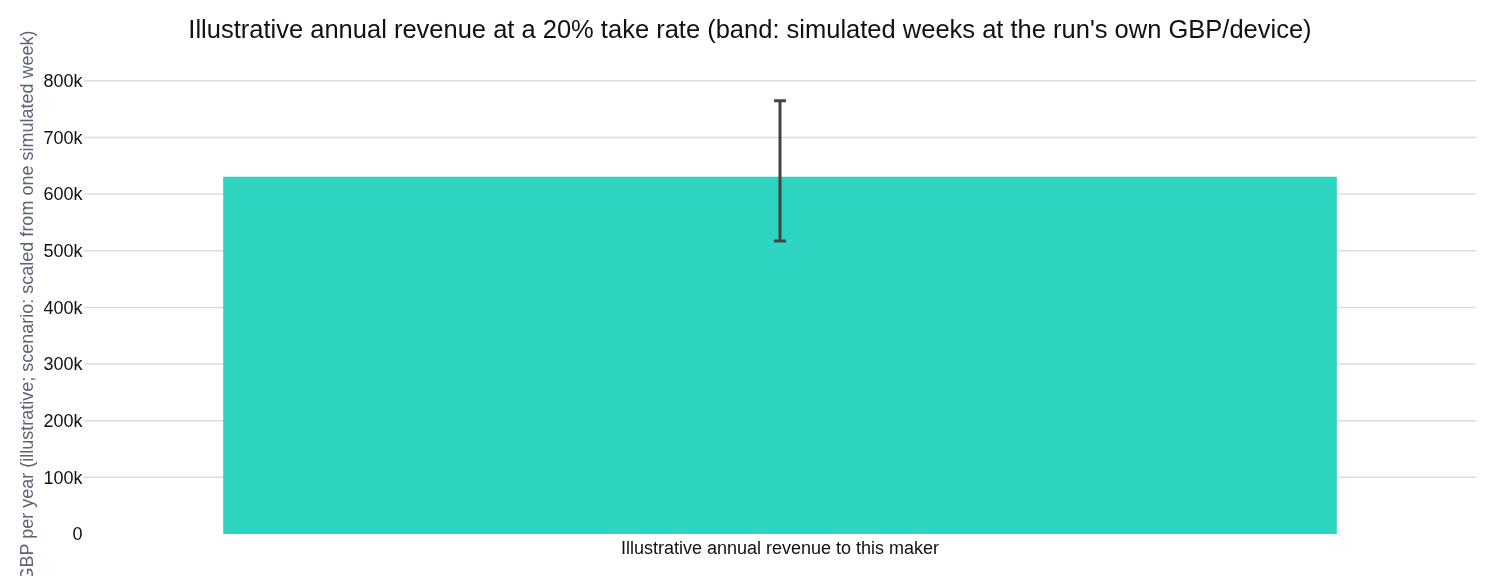

In [34]:
active_devices = float(funnel_table.set_index("stage").loc["active", "count"])
annual_band = {
    q: growth.annual_gbp(
        enrolled_devices=active_devices,
        gbp_per_enrolled_device_per_month=fleet_gross_per_enrolled[q],
        take_rate=TAKE_RATE_TRY_IT,
        fee_gbp_per_device_per_month=FEE_TRY_IT,
    )
    for q in ("p10", "p50", "p90")
}
annual_figure = go.Figure(
    go.Bar(
        x=["Illustrative annual revenue to this maker"],
        y=[annual_band["p50"]],
        error_y={
            "type": "data",
            "symmetric": False,
            "array": [annual_band["p90"] - annual_band["p50"]],
            "arrayminus": [annual_band["p50"] - annual_band["p10"]],
        },
        marker_color=SERIES_COLOURS["selected"],
    )
)
annual_figure.update_layout(
    title=(
        f"Illustrative annual revenue at a {TAKE_RATE_TRY_IT:.0%} take rate "
        "(band: simulated weeks at the run's own GBP/device)"
    ),
    yaxis_title="GBP per year (illustrative; scenario: scaled from one simulated week)",
    showlegend=False,
)
apply_notebook_style(annual_figure, height=340)

In [35]:
pd.Series(annual_band, name="GBP per year").to_frame().round(0)

,GBP per year
p10,517335.0
p50,630724.0
p90,764674.0


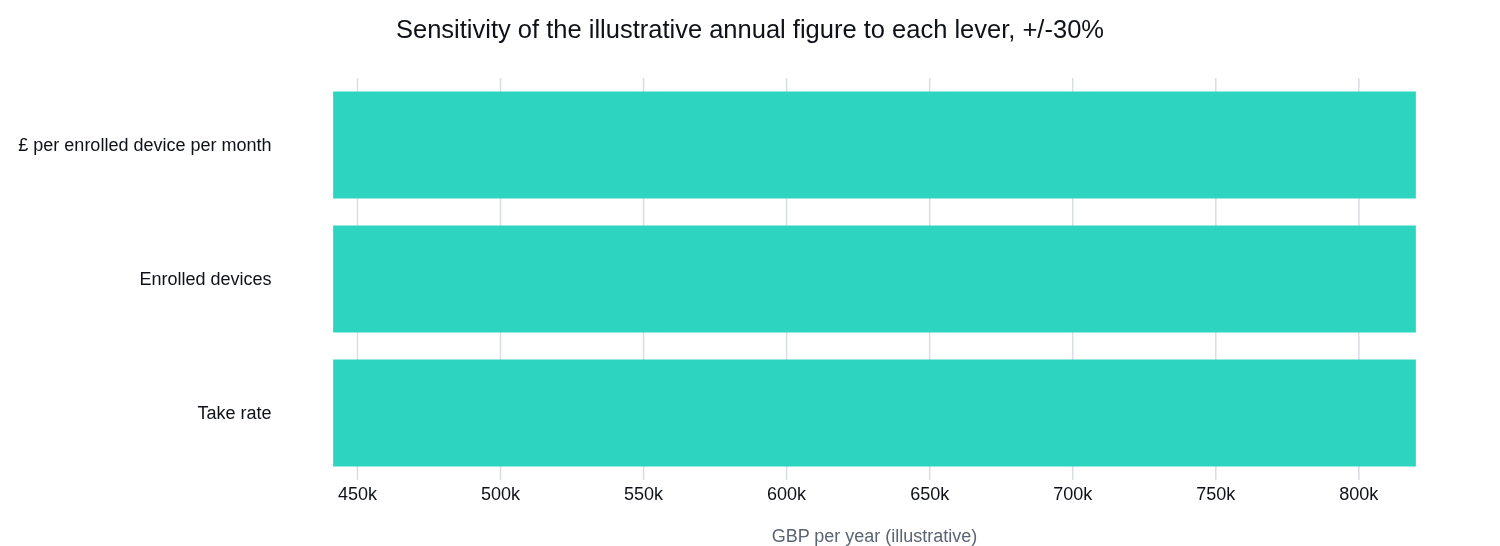

In [36]:
tornado_table = growth.tornado(
    enrolled_devices=active_devices,
    gbp_per_enrolled_device_per_month=float(fleet_gross_per_enrolled["p50"]),
    take_rate=TAKE_RATE_TRY_IT,
    fee_gbp_per_device_per_month=FEE_TRY_IT,
    swing=0.3,
)
tornado_figure = go.Figure()
for _, row in tornado_table.iterrows():
    tornado_figure.add_trace(
        go.Bar(
            y=[row["label"]],
            x=[row["annual_gbp_high"] - row["annual_gbp_low"]],
            base=[row["annual_gbp_low"]],
            orientation="h",
            marker_color=SERIES_COLOURS["selected"],
            showlegend=False,
        )
    )
tornado_figure.update_layout(
    title="Sensitivity of the illustrative annual figure to each lever, +/-30%",
    xaxis_title="GBP per year (illustrative)",
)
apply_notebook_style(tornado_figure, height=320)

In [37]:
tornado_table.round(1)

,lever,label,value,low_value,high_value,annual_gbp_low,annual_gbp_high,clipped
0,take_rate,Take rate,0.2,0.1,0.3,441506.9,819941.3,False
1,enrolled_devices,Enrolled devices,12000.0,8400.0,15600.0,441506.9,819941.3,False
2,gbp_per_enrolled_device_per_month,£ per enrolled device per month,21.9,15.3,28.5,441506.9,819941.3,False


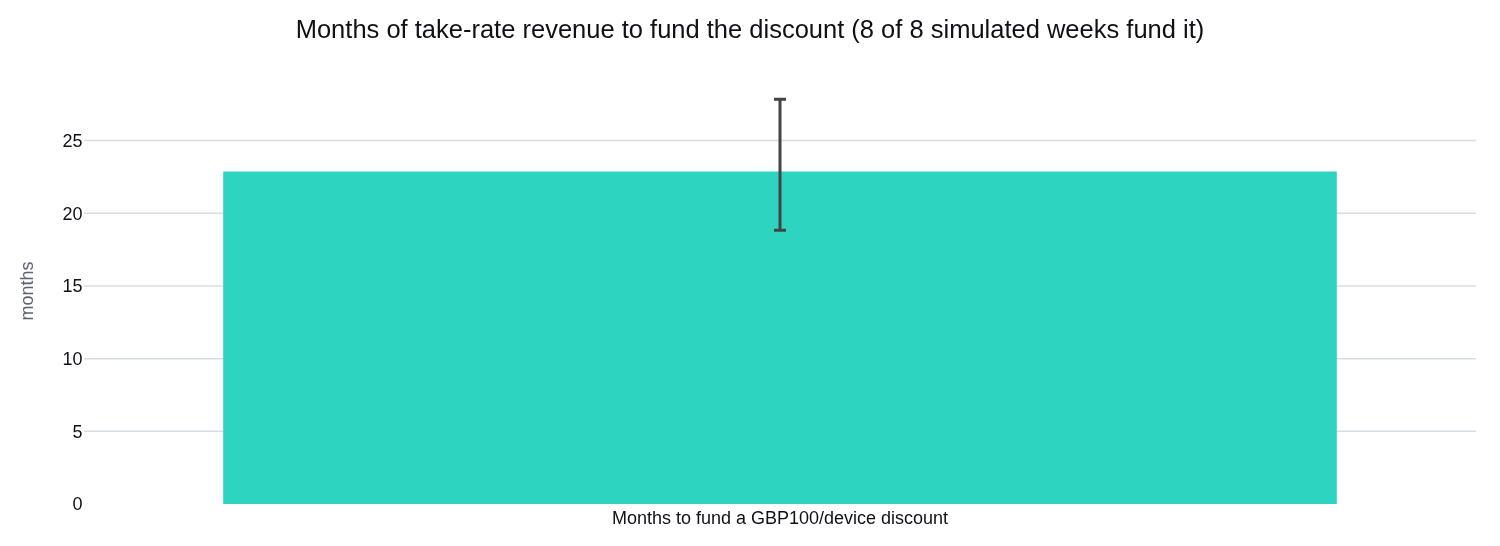

In [38]:
fleet_gross_per_enrolled_by_world = (
    base.partner_world.query("group_type == 'fleet'")
    .sort_values("world_id")["gross_flex_gbp_per_enrolled_device_per_month"]
    .to_numpy()
)
months_p10, months_p50, months_p90, months_world_count = growth.months_to_fund_discount(
    DISCOUNT_TRY_IT,
    gbp_per_enrolled_device_per_month_by_world=fleet_gross_per_enrolled_by_world,
    take_rate=TAKE_RATE_TRY_IT,
)
months_figure = go.Figure(
    go.Bar(
        x=[f"Months to fund a GBP{DISCOUNT_TRY_IT:g}/device discount"],
        y=[months_p50],
        error_y={
            "type": "data",
            "symmetric": False,
            "array": [months_p90 - months_p50],
            "arrayminus": [months_p50 - months_p10],
        },
        marker_color=SERIES_COLOURS["selected"],
    )
)
months_figure.update_layout(
    title=(
        f"Months of take-rate revenue to fund the discount "
        f"({months_world_count} of {base.world_count} simulated weeks fund it)"
    ),
    yaxis_title="months",
    showlegend=False,
)
apply_notebook_style(months_figure, height=320)

In [39]:
pd.DataFrame(
    [{"p10": months_p10, "p50": months_p50, "p90": months_p90, "world_count": months_world_count}]
).round(2)

,p10,p50,p90,world_count
0,18.83,22.87,27.84,8


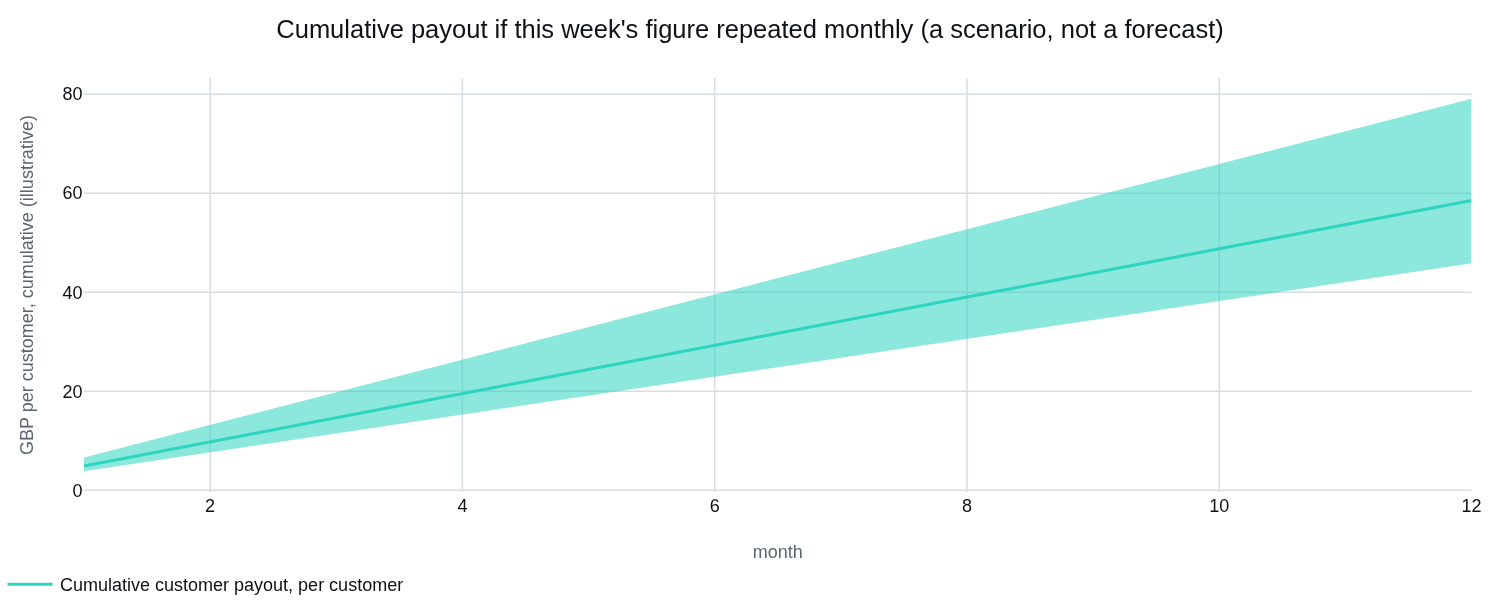

In [40]:
customer_payment_row = base.supplier_pnl_summary.query(
    "hedge_variant == 'profiled' and metric == 'customer_payment_per_customer_per_month_gbp'"
).iloc[0]
# customer_payment_gbp is the supplier's own cash flow (<= 0, a cost); the fan is the customer's
# payout, so it is sign-flipped, and the flip also swaps which quantile is which (the supplier's
# worst case, most negative, is the customer's best case).
payout_fan = growth.cumulative_payout_fan(
    monthly_gbp_p10=-customer_payment_row["p90"],
    monthly_gbp_p50=-customer_payment_row["p50"],
    monthly_gbp_p90=-customer_payment_row["p10"],
    months=12,
)

fan_figure = go.Figure()
band_and_line(
    fan_figure,
    payout_fan["month"],
    payout_fan["cumulative_p10"],
    payout_fan["cumulative_p50"],
    payout_fan["cumulative_p90"],
    name="Cumulative customer payout, per customer",
    colour=SERIES_COLOURS["selected"],
)
fan_figure.update_layout(
    title="Cumulative payout if this week's figure repeated monthly (a scenario, not a forecast)",
    xaxis_title="month",
    yaxis_title="GBP per customer, cumulative (illustrative)",
)
apply_notebook_style(fan_figure, height=360)

In [41]:
payout_fan.round(2)

,month,cumulative_p10,cumulative_p50,cumulative_p90
0,1,3.82,4.88,6.59
1,2,7.64,9.76,13.18
2,3,11.47,14.63,19.77
3,4,15.29,19.51,26.36
4,5,19.11,24.39,32.95
5,6,22.93,29.27,39.54
6,7,26.76,34.14,46.13
7,8,30.58,39.02,52.72
8,9,34.40,43.90,59.31
9,10,38.22,48.78,65.90


In [42]:
checks["growth: funnel stage counts multiply through, and earning = active x share_earning"] = (
    np.isclose(
        funnel_table.set_index("stage").loc["earning", "count"],
        active_devices * fleet_share_earning,
    )
)
checks["growth: the P10-P90 annual band equals the quantiles of a per-world recomputation"] = (
    np.allclose(
        [annual_band[q] for q in ("p10", "p50", "p90")],
        np.quantile(
            active_devices * fleet_gross_per_enrolled_by_world * TAKE_RATE_TRY_IT * 12.0,
            (0.1, 0.5, 0.9),
            method="linear",
        ),
    )
)
funded_worlds = fleet_gross_per_enrolled_by_world[fleet_gross_per_enrolled_by_world > 0]
checks["growth: months_to_fund_discount matches a hand per-world recompute"] = np.allclose(
    [months_p10, months_p50, months_p90],
    np.quantile(
        DISCOUNT_TRY_IT / (funded_worlds * TAKE_RATE_TRY_IT), (0.1, 0.5, 0.9), method="linear"
    ),
)
checks["growth: the payout fan is exactly month x the monthly figure, every row"] = np.allclose(
    payout_fan["cumulative_p50"].to_numpy(),
    payout_fan["month"].to_numpy() * (-customer_payment_row["p50"]),
)

## 9. Sanity checks

Every check below can fail: each one recomputes a contract identity from this notebook's own
frames, or from a toy fixture, using no number typed in by hand except the contract's own worked
example.


In [43]:
failed = [name for name, passed in checks.items() if not passed]
assert not failed, failed
pd.Series(checks, name="passed").to_frame()

,passed
toy: gross gain matches the worked example (GBP0.46/week),True
toy: a mis-timed x^U and x leaves the paired hedge-error saving unchanged,True
"toy: an unset platform fee makes the after-fee net unavailable (NaN), not GBP0",True
toy: a GBP1/EV/month fee gives the contract's own hand value (-GBP0.4615/week),True
"real run: hedge-error saving recomputes exactly from R, F and (SIP-P)",True
real run: the forecast turn-down F sums to 0 over every night (section 2 change),True
every world: gross gain = energy saving + hedge-error saving + grid-event payment,True
every world: net before fee = gross gain + customer payment,True
every world: energy saving equals minus the Value-and-risk lens's own cost_effect column,True
every world: shape saving + volume value = energy saving ('of which'),True


## 10. Limitations

- The retail tariff itself is not modelled: this P&L assumes a flat, non-time-of-use tariff, and
  the supplier's own retail margin on any volume change is out of scope.
- Supplier intraday re-hedging is not modelled: the supplier's hedge is bought once, day-ahead,
  and its error settles at the imbalance price; only the aggregator (the ledger, shown beside)
  trades intraday.
- `units.manufacturer_id` (firm-MW J1a) and `plan_status` (J1b) have both landed, so the partner
  tiles above already split by maker, `dispatch_success_rate` is the run's own figure (section 5)
  and `household_card`'s own availability profile populates (section 7) rather than reading NaN
  or `None`.
- The firm-MW product frames (`product_sheet`, `charge_completion_summary`,
  `firmness_by_manufacturer`, lane J5) have also landed and build on every action run; this
  notebook does not yet show them (they are the Supplier and Partners lenses' own Firm MW tiles,
  not part of the supplier P&L, partner or household frames this notebook walks through), so
  nothing here fabricates or restates their figures.
- The funnel's conversion shares, the take rate, the fee and the discount in section 8 are
  illustrative placeholders with no accepted source in this project (supplier contract v1 section
  16 Q7); the model contributes only `share_earning`.
- Carbon intensity is an illustrative synthetic mix intensity tied to the model's own net demand,
  not observed grid carbon data, and not a marginal intensity.
- The cumulative payout fan assumes the months are fully correlated (the same simulated week
  repeating); independent months would give a narrower band, so this is the wider, more
  conservative reading -- a scenario, not a forecast.
- The small run here (80 EVs, 8 simulated weeks) is for speed: its P10-P90 spreads are wider than
  the app's default 1,000 EV x 100 week run, and a few of the quantities above may look rougher
  than they would at full scale.
